# Notebook 4 — Fix generalisation + memory-aware erase gate → a final PROCEED / STOP decision

**Why this notebook?** Notebook 3 gave three messages:
1. The memory still generalised badly to **new wordings**. On the honest test only about 50–56% of unchanged facts were kept, compared with about 88% on seen wordings. New *names* were already fine.
2. B (working eraser) beat A (Metis as released) on updates by +10 points in 3/3 seeds. This was the solid finding.
3. C (separate erase knob) learned *when* to erase, but only from update **words**. On a silent update ("Rafi Singh resides in Oslo.") it did not erase at all. A gate that sees only the current sentence *cannot* know that something was already stored.

**What this notebook changes**

| Fix | What is done |
|---|---|
| **Fix 1 — wording generalisation** | About 3× more wordings: **16 statement, 14 update, 12 question** wordings per attribute for training, plus 6 / 5 / 5 **held-out** wordings for testing (the Notebook 3 test wordings are kept inside the held-out set). Training sentences also get random lead-ins ("By the way, …", "Apparently, …") and every training fact is written in **2 different wordings**. |
| **Fix 1 — diagnosis** | Two extra test conditions show whether the remaining gap comes from the **statements** or from the **questions**. |
| **Fix 2 — memory-aware erase gate (version D)** | D = C plus a small network that also looks at **what is already stored under the key** (how much is there, and whether it agrees with the new value). It starts exactly like C (last layer initialised to zero), so any difference is learned. |
| **Fair test for silent updates** | 30% of updates in training are written as plain statements, the **same for all versions**. So every version gets the chance to learn silent updates; only D has the information to do it. |
| **More reliable numbers** | 5 seeds instead of 3. A decision is only counted if the sign agrees in at least 4 of 5 seeds. |

**The four memory versions (everything else identical, same parameter count):**

| Version | What it does |
|---|---|
| **A** | Metis as released: tiny keys, so the eraser is almost off. One knob (β) for writing and erasing. |
| **B** | Normal-size keys, so the eraser works. Still one knob (the "simple fix"). |
| **C** | Like B, but with a separate erase knob that reads only the current sentence (Notebook 3's idea). |
| **D (NEW)** | Like C, but the erase knob also reads the memory: "is something already stored here, and does it disagree with the new fact?" |

**The final cell prints ONE decision** from rules fixed in `CONFIG` **before** any result is seen:
**PROCEED** (the idea works), **PROCEED – PARTIAL**, **STOP EXPERIMENTING – WRITE UP**, or **MOVE ON**.

**Kaggle settings:** GPU T4 · Internet On · Secret `HF_TOKEN`.
**Time:** about 20–25 min to encode sentences, about 4 min for the quick check, then about 10–12 min per run × 20 runs, which comes to **roughly 4–4.5 hours**.
**Recommended:** use **Save Version → Save & Run All (Commit)** so it runs in the background (Kaggle allows 12 h). Results are saved after every run. If an interactive session stops, run everything again and finished runs are skipped.
To save time you can set `"seeds": [1, 2, 3]` in Cell 3 (about 2.5 h). The decision still works, but then it needs 3/3 seed agreement.

In [1]:
# CELL 1 -- Install the exact Transformers version Metis was saved with
!pip install -q "transformers==5.4.0" accelerate

import transformers
from transformers.models.auto.configuration_auto import CONFIG_MAPPING_NAMES

print("Transformers version:", transformers.__version__)
print("Loaded from        :", transformers.__file__)

qwen_models = []
for model_type in CONFIG_MAPPING_NAMES:
    if model_type.startswith("qwen"):
        qwen_models.append(model_type)
print("Qwen models this version knows:", qwen_models)

if "qwen3_5" in qwen_models:
    print("\nOK: qwen3_5 is supported. Continue with Cell 2.")
else:
    print("\nPROBLEM: qwen3_5 is NOT supported. Share this output.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 101.2 MB/s eta 0:00:0000:010:01
Transformers version: 5.4.0
Loaded from        : /usr/local/lib/python3.12/dist-packages/transformers/__init__.py
Qwen models this version knows: ['qwen2', 'qwen2_5_omni', 'qwen2_5_vl', 'qwen2_5_vl_text', 'qwen2_audio', 'qwen2_audio_encoder', 'qwen2_moe', 'qwen2_vl', 'qwen2_vl_text', 'qwen3', 'qwen3_5', 'qwen3_5_moe', 'qwen3_5_moe_text', 'qwen3_5_text', 'qwen3_moe', 'qwen3_next', 'qwen3_omni_moe', 'qwen3_vl', 'qwen3_vl_moe', 'qwen3_vl_moe_text', 'qwen3_vl_text']

OK: qwen3_5 is supported. Continue with Cell 2.


In [2]:
# CELL 2 -- HuggingFace login
from huggingface_hub import login
from kaggle_secrets import UserSecretsClient

try:
    user_secrets = UserSecretsClient()
    secret_value_0 = user_secrets.get_secret("HF_TOKEN")
    login(secret_value_0)
    print("HuggingFace login done")
except Exception as error:
    print("Login skipped (Qwen2.5 is public, so this is usually fine).")
    print("Reason:", error)

HuggingFace login done


In [3]:
# CELL 3 -- Imports + GPU + settings
import os
import json
import math
import random
import time
import gc
import shutil

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from tqdm.auto import tqdm

OUTPUT_DIR = "/kaggle/working/metis_notebook4"   # NEW folder, so Notebook 3 results are never mixed in
os.makedirs(OUTPUT_DIR, exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"PyTorch : {torch.__version__}")
if DEVICE == "cuda":
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("GPU     : none (training will be very slow)")
print(f"Output  : {OUTPUT_DIR}")

CONFIG = {
    # Frozen language model that turns sentences into vectors (never trained here)
    "feature_model"          : "Qwen/Qwen2.5-1.5B-Instruct",
    "feature_layer"          : 18,        # which hidden layer to read (Qwen2.5-1.5B has 28)
    "encode_batch_size"      : 128,
    "encode_prefix"          : "Sentence:",   # fixed start; its tokens are skipped when averaging

    # People
    "n_train_people"         : 400,       # full names made from TRAIN first x TRAIN last names
    "n_test_people"          : 100,       # full names made from TEST first x TEST last names (never seen)
    "n_wording_probe_people" : 60,        # training people also written with the unseen wordings
    "pool_seed"              : 0,         # fixes which people and wordings are chosen

    # FIX 1: more wording variety in training
    "train_sentences_per_fact"   : 2,     # every training fact exists in 2 different wordings
    "train_questions_per_person" : 6,     # question wordings sampled per (training person, attribute)
    "wrapper_probability"        : 0.5,   # chance a training sentence gets a lead-in ("By the way, ...")
    "train_silent_update_fraction": 0.3,  # share of training updates written as plain statements (ALL versions)

    # Memory settings (copied from Metis where possible)
    "memory_size"            : 512,
    "update_ratio"           : 0.9,       # same as Metis config.json
    "gate_start_logit"       : 4.0,       # gates start at sigmoid(4) = 0.98
    "feature_dropout"        : 0.1,       # small noise during training only (same for all versions)

    # FIX 2: memory-aware erase gate (used only by version D; created in all versions)
    "memory_gate_context_size": 16,       # small summary of the sentence given to the memory gate
    "memory_gate_hidden"      : 32,

    # Story (episode) shape used in training and in the main tests
    "people_per_episode"     : 2,
    "facts_per_person"       : 4,
    "fillers_per_episode"    : 2,
    "max_updates_per_episode": 2,

    # Training (identical for all versions)
    "train_steps"            : 3000,
    "warmup_steps"           : 100,
    "batch_size"             : 64,
    "learning_rate"          : 0.001,
    "print_every"            : 250,
    "seeds"                  : [1, 2, 3],
    "versions"               : ["A", "B", "C", "D"],

    # Quick check before the long runs
    "quick_check_steps"      : 800,
    "quick_check_floor"      : 35.0,      # stop if B keeps < this % of unchanged facts on the honest test
    "stop_if_quick_check_fails": True,
    "smoke_test_steps"       : 100,       # tiny D run, only to catch errors before the long runs

    # Testing
    "test_seed"              : 999,       # FIXED: every version is tested on the same stories
    "n_test_episodes"        : 2000,      # per condition; each test story has exactly ONE update
    "n_long_episodes"        : 500,
    "long_people"            : 5,         # long story: 5 people x 6 facts + 10 fillers = 40 writes
    "long_fillers"           : 10,
    "long_checkpoints"       : [1, 5, 10, 20, 30, 40],
    "eval_batch_size"        : 100,

    # ---------------------------------------------------------------------------------------------
    # DECISION RULES -- written BEFORE seeing any result (percentage points unless stated)
    # ---------------------------------------------------------------------------------------------
    "gen_strong"             : 65.0,  # avg honest 'unchanged facts kept' >= this -> test bed is good
    "gen_weak"               : 55.0,  # >= this -> usable; below -> results are not trustworthy
    "eraser_margin"          : 5.0,   # E: B must beat A on updates by at least this
    "silent_margin"          : 5.0,   # S: D must beat C on silent updates by at least this
    "beat_simple_fix_margin" : 3.0,   # X: D must beat B (silent or normal updates) by at least this
    "damage_tolerance"       : 3.0,   # SAFE: D may lose at most this vs B on facts that did not change
    "mechanism_ratio"        : 0.5,   # M: D's erase on silent updates >= this x its erase on normal updates
    "seed_agreement"         : 0.8,   # a difference counts only if its sign agrees in >= 80% of seeds

    # Files
    "features_file"          : f"{OUTPUT_DIR}/sentence_features.pt",
    "results_file"           : f"{OUTPUT_DIR}/results.json",
    "loss_file"              : f"{OUTPUT_DIR}/loss_curves.json",
}

VERSION_DESCRIPTIONS = {
    "A": "A: Metis as released (tiny keys, eraser ~off)",
    "B": "B: normal keys (eraser on, one knob)",
    "C": "C: separate erase knob (sentence only)",
    "D": "D: memory-aware erase knob (NEW)",
}
VERSION_COLORS = {"A": "tab:gray", "B": "tab:orange", "C": "tab:green", "D": "tab:blue"}

# Notebook 3 honest-test numbers, only used as a reference line in the tables
NOTEBOOK3_HONEST = {
    "A": {"unchanged_kept": 50.6, "update_correct": 36.9},
    "B": {"unchanged_kept": 55.7, "update_correct": 47.0},
    "C": {"unchanged_kept": 55.5, "update_correct": 39.5},
}

# Every metric: (short name, what it measures, which direction is good)
METRIC_GUIDE = {
    "update_correct": ("Updated fact correct (%)",
                       "A fact changed during the story (e.g. the person moved). How often the memory gives the NEW value.",
                       "HIGHER is better"),
    "update_gave_old": ("Gave the OLD value (%)",
                        "For the same changed facts: how often the memory gives the value that was replaced "
                        "(a stale memory the eraser failed to remove).",
                        "LOWER is better"),
    "same_person_kept": ("Same-person facts kept (%)",
                         "Facts that did NOT change but belong to the person who had an update. "
                         "Shows whether erasing damaged that person's other facts.",
                         "HIGHER is better"),
    "unchanged_kept": ("All unchanged facts kept (%)",
                       "Every fact that did not change, for both people. General memory quality.",
                       "HIGHER is better"),
    "long_first_after_40": ("First fact after 40 writes (%)",
                            "Long story of 40 sentences: is the very first fact still recalled at the end? "
                            "Measures long-range forgetting.",
                            "HIGHER is better"),
    "long_all_final": ("All 30 facts at end of long story (%)",
                       "Long story: how many of the 30 facts are recalled after all 40 sentences.",
                       "HIGHER is better"),
    "erase_on_filler": ("Erase on filler sentences (0 to 0.9)",
                        "How strongly the memory erases when the sentence is small talk ('The sky looks cloudy.').",
                        "NO better/worse (diagnostic only)"),
    "erase_on_new_fact": ("Erase on NEW facts (0 to 0.9)",
                          "Erasing while storing a brand-new fact. Nothing should be removed, and because keys "
                          "overlap, erasing here can damage older facts.",
                          "LOWER is better"),
    "erase_on_update": ("Erase on UPDATES (0 to 0.9)",
                        "Erasing when a fact changes. This is exactly when the old value should be removed.",
                        "HIGHER is better"),
    "silent_update_correct": ("Silent update correct (%)",
                              "Same as 'Updated fact correct', but the change is written as a plain statement "
                              "('Rafi Singh resides in Oslo.') with no word like 'moved' or 'now'.",
                              "HIGHER is better"),
    "silent_update_gave_old": ("Silent update gave OLD value (%)",
                               "For silent updates: how often the replaced value is given.",
                               "LOWER is better"),
    "silent_same_person_kept": ("Silent: same-person facts kept (%)",
                                "Silent-update stories: facts of the updated person that did NOT change. "
                                "Shows whether erasing on plain statements damages other facts.",
                                "HIGHER is better"),
    "silent_erase_on_update": ("Erase on SILENT updates (0 to 0.9)",
                               "Erase strength on plainly-worded changes. High = the model notices the change from "
                               "meaning. Low = it only reacts to words like 'moved' or 'now'.",
                               "HIGHER is better"),
    "generalization_gap": ("Generalization gap (points)",
                           "Seen-wordings score minus honest-test score. Small gap = the memory learned a general "
                           "skill; big gap = it memorised the training wordings.",
                           "LOWER is better"),
    "retention_curve": ("First fact recalled after N writes (%)",
                        "Long story: the first fact is asked again after 1, 5, 10, 20, 30 and 40 sentences.",
                        "HIGHER is better"),
    "paired_difference": ("Paired difference (points)",
                          "Same seed, same test stories: version X minus version Y. Positive = X scored more. "
                          "For 'Gave the OLD value' and 'Erase on NEW facts' a NEGATIVE difference is the good one. "
                          "'4/5' = the sign was the same in 4 of 5 seeds.",
                          "see each metric"),
}


def print_metric_guide(metric_keys, title):
    print("=" * 96)
    print(title)
    print("-" * 96)
    print("WHAT THE NUMBERS MEAN:")
    for key in metric_keys:
        short_name, meaning, direction = METRIC_GUIDE[key]
        print(f"  * {short_name}   -->  {direction}")
        print(f"      {meaning}")
    print("-" * 96)


print("Settings ready.")

PyTorch : 2.10.0+cu128
GPU     : Tesla T4
VRAM    : 15.6 GB
Output  : /kaggle/working/metis_notebook4
Settings ready.


In [4]:
# CELL 4 -- Vocabulary: names, facts, sentence wordings  (FIX 1: many more wordings)
# Names: a person is "First Last". Training and test use completely different first AND last names.
# Wordings: "train" wordings are used in training; "test" wordings are NEVER seen in training.
# The Notebook 3 test wordings are kept inside the "test" lists, so results stay comparable.

TRAIN_FIRST_NAMES = ["Alice", "Rahim", "Maria", "Kenji", "Fatima", "Omar", "Lena", "Arjun", "Sofia", "Yusuf",
                     "Hana", "Diego", "Nora", "Tariq", "Emma", "Ravi", "Chloe", "Ahmed", "Mei", "Lucas",
                     "Priya", "Jonas", "Amara", "Ivan", "Leila", "Mateo", "Sara", "Kofi", "Anya", "Bilal",
                     "Grace", "Hiro", "Zara", "Felix", "Nadia", "Pablo", "Ines", "Sami", "Tara", "Victor",
                     "Olga", "Samir"]
TEST_FIRST_NAMES = ["Rafi", "Elena", "Musa", "Clara", "Joon", "Selin", "Adnan", "Maya", "Tomas", "Rina",
                    "Karim", "Julia", "Nikhil"]
TRAIN_LAST_NAMES = ["Chen", "Silva", "Khan", "Novak", "Okafor", "Garcia", "Tanaka", "Rossi", "Haddad", "Kowalski",
                    "Mensah", "Patel", "Nguyen", "Schmidt", "Moreau", "Ivanov", "Costa", "Hansen", "Rahman", "Suzuki",
                    "Lopez", "Ali", "Petrov", "Murphy", "Fischer", "Kim", "Yilmaz", "Das", "Mendes", "Olsen",
                    "Bauer", "Sato", "Diaz", "Kaya", "Wright", "Park", "Hossain", "Lindqvist", "Mwangi", "Romano",
                    "Castro", "Weber"]
TEST_LAST_NAMES = ["Morales", "Jensen", "Chowdhury", "Adeyemi", "Takahashi", "Russo", "Nakamura", "Dubois",
                   "Ortega", "Singh", "Varga", "Lee", "Popescu"]

assert len(set(TRAIN_FIRST_NAMES) & set(TEST_FIRST_NAMES)) == 0, "first names overlap"
assert len(set(TRAIN_LAST_NAMES) & set(TEST_LAST_NAMES)) == 0, "last names overlap"


def with_article(value):
    if value[0].lower() in "aeiou":
        return "an " + value
    return "a " + value


# {name} = full name, {value} = the fact, {a_value} = the fact with "a"/"an"
ATTRIBUTES = {
    "city": {
        "values": ["Dhaka", "Tokyo", "Paris", "London", "Cairo", "Lima", "Oslo", "Berlin", "Madrid", "Rome",
                   "Nairobi", "Sydney", "Toronto", "Chicago", "Mumbai", "Seoul", "Bangkok", "Dubai", "Lisbon", "Vienna"],
        "statements": {
            "train": ["{name} lives in {value}.", "{name}'s home is in {value}.", "{name} is based in {value}.",
                      "{name} has an apartment in {value}.", "{name} spends most of the year in {value}.",
                      "The city {name} calls home is {value}.", "{name} makes a home in {value}.",
                      "{name} is a resident of {value}.", "{name} lives and works in {value}.",
                      "Home for {name} is {value}.", "{name} rents a flat in {value}.",
                      "{name}'s current city is {value}.", "You can find {name} in {value}.",
                      "{name}'s house is in {value}.", "{name} stays in {value}.",
                      "{name} lives in the city of {value}."],
            "test": ["{name} resides in {value}.", "{name}'s address is in {value}.", "{name} dwells in {value}.",
                     "The place {name} lives is {value}.", "{name} has a residence in {value}.",
                     "{name} occupies a home in {value}."]},
        "updates": {
            "train": ["{name} moved to {value}.", "{name} has relocated to {value}.", "{name} now lives in {value} instead.",
                      "{name} left the old city and settled in {value}.", "These days {name} is living in {value}.",
                      "{name} recently moved to {value}.", "{name} relocated to {value} last month.",
                      "{name} no longer lives in the old city; it is {value} now.", "{name} has since moved to {value}.",
                      "{name} went to live in {value}.", "After moving, {name} lives in {value}.",
                      "{name} is now based in {value}.", "{name} transferred to {value}.",
                      "{name} made the move to {value}."],
            "test": ["{name} recently packed up and settled in {value}.", "{name} changed cities and is now in {value}.",
                     "{name} left for {value} and stayed there.", "{name}'s new home city is {value}.",
                     "{name} uprooted and started over in {value}."]},
        "questions": {
            "train": ["Where does {name} live?", "Which city is {name} based in?", "What city is {name}'s home?",
                      "Where is {name} living?", "Where is {name}'s home?", "What city does {name} live in?",
                      "Which city does {name} call home?", "Where is {name} based?", "Tell me where {name} lives.",
                      "In what city is {name} living?", "Where can {name} be found?", "Name the city where {name} lives."],
            "test": ["In which city does {name} reside?", "What is {name}'s city of residence?",
                     "Where has {name} made a home?", "Which city is home to {name}?",
                     "What is the home city of {name}?"]},
    },
    "job": {
        "values": ["doctor", "teacher", "pilot", "chef", "nurse", "lawyer", "farmer", "dentist", "architect", "plumber",
                   "journalist", "engineer", "painter", "banker", "librarian", "firefighter", "baker", "pharmacist",
                   "electrician", "photographer"],
        "statements": {
            "train": ["{name} works as {a_value}.", "{name} is {a_value} by profession.", "{name} earns a living as {a_value}.",
                      "{name} has a job as {a_value}.", "By trade, {name} is {a_value}.",
                      "{name} trained as {a_value} and works as one.", "{name} is {a_value}.",
                      "{name} has worked as {a_value} for years.", "{name}'s job is being {a_value}.",
                      "{name} is a professional {value}.", "{name}'s occupation is {value}.",
                      "{name} works full-time as {a_value}.", "At work, {name} is {a_value}.",
                      "{name} holds a position as {a_value}.", "{name} does the job of {a_value}.",
                      "{name} spends the workday as {a_value}."],
            "test": ["{name} is employed as {a_value}.", "{name} makes a career as {a_value}.",
                     "{name} practices as {a_value}.", "{name}'s line of work is {value}.",
                     "For a living, {name} serves as {a_value}.", "{name} is on staff as {a_value}."]},
        "updates": {
            "train": ["{name} changed careers and is now {a_value}.", "{name} now works as {a_value}.",
                      "{name} quit the old job and became {a_value}.", "{name} has a new job as {a_value}.",
                      "After a career change, {name} is {a_value}.", "{name} became {a_value} recently.",
                      "{name} started a new job as {a_value}.", "{name} is now {a_value} instead.",
                      "{name} left the old job to work as {a_value}.", "{name} has since become {a_value}.",
                      "{name} took a new position as {a_value}.", "{name} moved into a new career as {a_value}.",
                      "{name} got hired as {a_value}.", "These days {name} works as {a_value}."],
            "test": ["{name} switched professions to become {a_value}.", "{name} retrained and now works as {a_value}.",
                     "{name} gave up the previous career to be {a_value}.",
                     "{name} traded the old career for work as {a_value}.", "{name}'s new profession is {value}."]},
        "questions": {
            "train": ["What is {name}'s job?", "What does {name} do for work?", "What is {name}'s occupation?",
                      "How does {name} earn a living?", "What does {name} do for a living?", "What job does {name} have?",
                      "Which job does {name} do?", "What does {name} work as?", "Tell me {name}'s job.",
                      "What is {name} by profession?", "What is {name}'s career?", "What position does {name} hold?"],
            "test": ["What is {name}'s profession?", "What kind of work does {name} do?", "How does {name} make money?",
                     "Which occupation does {name} have?", "What is {name} employed as?"]},
    },
    "food": {
        "values": ["pizza", "sushi", "biryani", "pasta", "tacos", "ramen", "curry", "salad", "burgers", "dumplings",
                   "paella", "kebab", "noodles", "pancakes", "falafel", "lasagna", "steak", "soup", "sandwiches", "waffles"],
        "statements": {
            "train": ["{name}'s favorite food is {value}.", "{name} loves eating {value}.",
                      "{name} enjoys {value} more than any other dish.", "Nothing beats {value} for {name}.",
                      "{name} would eat {value} every day.", "{name}'s go-to meal is {value}.",
                      "{name} likes {value} the most.", "{name}'s favorite meal is {value}.",
                      "{name} always orders {value}.", "{name}'s favorite dish is {value}.",
                      "{name} can't get enough of {value}.", "For {name}, the best food is {value}.",
                      "{name} loves {value}.", "{name} eats {value} whenever possible.",
                      "{name} is a big fan of {value}.", "{name}'s comfort food is {value}."],
            "test": ["{name}'s top dish is {value}.", "{name} craves {value} above all else.", "{name} adores {value}.",
                     "{name}'s number one food is {value}.", "If given a choice, {name} picks {value}.",
                     "{name} treasures a plate of {value}."]},
        "updates": {
            "train": ["{name}'s favorite food is now {value}.", "These days {name} prefers {value} over the old favorite.",
                      "{name} changed favorite food to {value}.", "{name} has a new favorite dish: {value}.",
                      "Lately {name} likes {value} best.", "{name} now loves {value} the most.",
                      "{name}'s new favorite food is {value}.", "{name} switched to {value} as a favorite.",
                      "{name} used to love another dish but now prefers {value}.", "Now {name}'s favorite meal is {value}.",
                      "{name} has come to prefer {value}.", "{name} discovered {value} and now likes it best.",
                      "{name} has a new go-to meal: {value}.", "{name} now orders {value} every time."],
            "test": ["{name} has grown tired of the old dish and now craves {value}.",
                     "{name}'s taste changed, and {value} is the new favorite.",
                     "{name} went off the old favorite and now picks {value}.",
                     "{name}'s preferred dish has become {value}.",
                     "{name} fell for {value} and dropped the old favorite."]},
        "questions": {
            "train": ["What is {name}'s favorite food?", "Which dish does {name} like best?",
                      "What does {name} love to eat?", "What is {name}'s go-to meal?", "What food does {name} like best?",
                      "What is {name}'s favorite dish?", "What does {name} like to eat most?",
                      "What would {name} eat every day?", "What is {name}'s favorite meal?",
                      "Tell me {name}'s favorite food.", "What does {name} always order?",
                      "What dish does {name} enjoy most?"],
            "test": ["What food does {name} love most?", "Which meal is {name}'s top choice?",
                     "What is {name}'s preferred dish?", "Which dish does {name} crave?",
                     "What food makes {name} happiest?"]},
    },
    "pet": {
        "values": ["cat", "dog", "parrot", "rabbit", "hamster", "turtle", "goldfish", "horse", "snake", "lizard",
                   "ferret", "pony", "canary", "hedgehog", "chinchilla", "guinea pig", "iguana", "frog", "tortoise", "gecko"],
        "statements": {
            "train": ["{name} has a pet {value}.", "{name} owns {a_value}.", "{name} takes care of a pet {value}.",
                      "{name} lives with {a_value}.", "{name}'s pet is {a_value}.", "At home, {name} looks after {a_value}.",
                      "{name} has {a_value}.", "{name} adopted {a_value} years ago.", "{name} shares a home with {a_value}.",
                      "{name}'s animal companion is {a_value}.", "{name} cares for {a_value}.",
                      "{name} feeds a pet {value} every day.", "{name} raised {a_value}.",
                      "The pet in {name}'s home is {a_value}.", "{name} has had {a_value} for a long time.",
                      "{name}'s household includes {a_value}."],
            "test": ["{name} keeps {a_value} at home.", "{name} is the proud owner of {a_value}.",
                     "{name}'s beloved pet is {a_value}.", "{name} provides a home for {a_value}.",
                     "{name} is devoted to a pet {value}.", "Living with {name} is {a_value}."]},
        "updates": {
            "train": ["{name} now has a pet {value} instead.", "{name} gave away the old pet and adopted {a_value}.",
                      "{name}'s pet is now {a_value}.", "{name} got a new pet, {a_value}.",
                      "{name} replaced the old pet with {a_value}.", "{name} adopted {a_value} and gave up the old pet.",
                      "{name}'s new pet is {a_value}.", "{name} now owns {a_value}.",
                      "{name} got {a_value} after the old pet left.", "{name} traded the old pet for {a_value}.",
                      "{name} now looks after {a_value} instead.", "{name} has switched to owning {a_value}.",
                      "{name} brought home {a_value} to replace the old pet.", "Now {name} has {a_value}."],
            "test": ["{name} rehomed the previous pet and got {a_value}.",
                     "{name} no longer has the old pet and now owns {a_value}.",
                     "{name} said goodbye to the old pet and welcomed {a_value}.",
                     "{name}'s pet these days is {a_value}.",
                     "{name} found a new home for the old pet and took in {a_value}."]},
        "questions": {
            "train": ["What pet does {name} have?", "What animal does {name} own?", "What is {name}'s pet?",
                      "Which animal lives with {name}?", "Which pet does {name} have?", "What pet does {name} own?",
                      "What animal is {name}'s pet?", "Tell me {name}'s pet.", "What animal does {name} care for?",
                      "What is the pet in {name}'s home?", "What pet lives in {name}'s house?",
                      "What animal did {name} adopt?"],
            "test": ["What kind of pet does {name} keep?", "What animal does {name} look after?",
                     "Which animal shares {name}'s home?", "What creature does {name} have at home?",
                     "Which animal belongs to {name}?"]},
    },
    "color": {
        "values": ["red", "blue", "green", "yellow", "purple", "orange", "pink", "brown", "black", "white",
                   "gray", "teal", "maroon", "navy", "gold", "silver", "beige", "violet", "olive", "cyan"],
        "statements": {
            "train": ["{name}'s favorite color is {value}.", "{name} likes the color {value} best.",
                      "{name} always picks {value} as a color.", "{name} loves the color {value}.",
                      "Most of {name}'s clothes are {value}.", "{name}'s favorite shade is {value}.",
                      "{name} really likes {value}.", "{name}'s best-loved color is {value}.",
                      "{name} paints everything {value}.", "{name} chooses {value} whenever possible.",
                      "{name} wears {value} a lot.", "The color {name} likes most is {value}.",
                      "{name} is fond of the color {value}.", "{name}'s room is painted {value}.",
                      "{name} adores the color {value}.", "{name} decorates with {value}."],
            "test": ["{name} prefers the color {value}.", "{name} is drawn to the color {value}.",
                     "{name} gravitates toward {value}.", "{name}'s signature color is {value}.",
                     "The shade {name} favors is {value}.", "{name} feels happiest surrounded by {value}."]},
        "updates": {
            "train": ["{name}'s favorite color is now {value}.", "{name} changed favorite color to {value}.",
                      "Lately {name} likes {value} better than the old color.",
                      "{name} now prefers {value} to any other color.", "{name} has a new favorite color: {value}.",
                      "{name} now likes {value} best.", "{name}'s new favorite color is {value}.",
                      "{name} switched favorite colors to {value}.", "These days {name} picks {value}.",
                      "{name} has come to love {value} instead.", "{name} now paints everything {value}.",
                      "{name} moved on from the old color to {value}.", "{name} now wears mostly {value}.",
                      "{name}'s favorite shade is now {value}."],
            "test": ["{name} no longer likes the old color and now chooses {value}.",
                     "{name}'s color taste shifted to {value}.",
                     "{name} abandoned the previous color and embraced {value}.",
                     "{name}'s preferred shade has turned into {value}.",
                     "{name} fell out of love with the old color and chose {value}."]},
        "questions": {
            "train": ["What is {name}'s favorite color?", "Which color does {name} like best?",
                      "What color does {name} love?", "What is {name}'s favorite shade?",
                      "What color does {name} like most?", "Which color is {name}'s favorite?",
                      "What is {name}'s best-loved color?", "Tell me {name}'s favorite color.",
                      "What color does {name} always pick?", "What color does {name} wear most?",
                      "Which shade does {name} like?", "What color is {name} fond of?"],
            "test": ["What color does {name} prefer?", "Which color is {name} drawn to?",
                     "What is {name}'s signature color?", "Which shade does {name} favor?",
                     "What hue does {name} love?"]},
    },
    "hobby": {
        "values": ["chess", "tennis", "painting", "hiking", "swimming", "cycling", "gardening", "fishing", "knitting", "dancing",
                   "boxing", "surfing", "archery", "pottery", "skating", "rowing", "climbing", "sailing", "golf", "yoga"],
        "statements": {
            "train": ["{name} enjoys {value}.", "{name}'s hobby is {value}.", "In free time, {name} does {value}.",
                      "{name} spends evenings on {value}.", "{name} is passionate about {value}.",
                      "{name} relaxes by doing {value}.", "{name} loves {value}.", "{name} likes doing {value}.",
                      "{name}'s favorite activity is {value}.", "{name} practices {value} every week.",
                      "{name} is really into {value}.", "After work, {name} does {value}.",
                      "{name} spends free time on {value}.", "{name} has a passion for {value}.",
                      "{name} takes part in {value} regularly.", "{name}'s main hobby is {value}."],
            "test": ["{name} spends weekends on {value}.", "{name}'s favorite pastime is {value}.",
                     "{name} unwinds with {value}.", "{name} devotes spare hours to {value}.",
                     "For leisure, {name} chooses {value}.", "{name} keeps busy with {value} outside work."]},
        "updates": {
            "train": ["{name} has switched to {value} as a hobby.", "{name}'s hobby is now {value}.",
                      "{name} stopped the old hobby and took up {value}.", "{name} recently started {value} instead.",
                      "{name} gave up the old hobby for {value}.", "{name} took up {value} recently.",
                      "{name}'s new hobby is {value}.", "{name} now spends free time on {value}.",
                      "{name} switched hobbies to {value}.", "{name} started doing {value} instead.",
                      "These days {name} is into {value}.", "{name} now loves {value} instead.",
                      "{name} replaced the old hobby with {value}.", "{name} has moved on to {value}."],
            "test": ["{name} dropped the previous hobby in favor of {value}.",
                     "{name} lost interest in the old hobby and picked up {value}.",
                     "{name} abandoned the former pastime and now does {value}.",
                     "{name}'s pastime has become {value}.", "{name} traded the old hobby for {value}."]},
        "questions": {
            "train": ["What is {name}'s hobby?", "What does {name} do for fun?", "How does {name} spend free time?",
                      "What is {name} passionate about?", "What does {name} like doing?",
                      "What is {name}'s favorite activity?", "What does {name} do in free time?",
                      "Tell me {name}'s hobby.", "What does {name} practice?", "What is {name} into?",
                      "What does {name} do after work?", "What activity does {name} enjoy?"],
            "test": ["Which hobby does {name} have?", "What pastime does {name} enjoy?", "How does {name} unwind?",
                     "What leisure activity does {name} pursue?", "What does {name} do to relax?"]},
    },
}
ATTRIBUTE_NAMES = list(ATTRIBUTES.keys())

FILLERS = {
    "train": ["The weather is nice today.", "I had coffee this morning.", "The train was late again.",
              "We watched a movie last night.", "The meeting ran long.", "It rained in the afternoon.",
              "The shop closes at eight.", "My phone battery is low.", "The park was crowded.",
              "Dinner was delicious.", "The bus stop moved last week.", "I finished reading a book.",
              "The internet was slow today.", "We cleaned the kitchen.", "The music was loud.",
              "The elevator is broken.", "Someone left the window open.", "The coffee machine is empty.",
              "The street was very quiet.", "My shoes got wet.", "The lights flickered for a moment.",
              "We ordered lunch at noon.", "The garden needs water.", "It was a long week.",
              "The fridge is making a noise.", "Our flight was delayed.", "The TV remote is missing.",
              "The office was cold today.", "I lost my umbrella again.", "The bakery sold out early.",
              "There was a long queue at the bank.", "The neighbors are painting their fence.",
              "The meeting was moved to Friday.", "The kettle just boiled.", "The road is under repair.",
              "My laptop needed an update.", "The concert tickets sold fast.", "It snowed a little overnight.",
              "The cat next door is very loud.", "The window cleaner came today."],
    "test": ["The sky looks cloudy.", "Traffic was heavy downtown.", "The library was quiet.",
             "Someone knocked on the door.", "The soup needed more salt.", "The printer ran out of paper.",
             "The clock on the wall stopped.", "A dog barked outside.", "The bridge was closed for repairs.",
             "The tea went cold on the desk.", "A storm is expected tonight.", "The parking lot was full.",
             "The doorbell battery died.", "The market smelled of fresh bread.", "The hallway light is dim."],
}

# FIX 1: lead-ins added (with 50% chance) to TRAINING sentences only, for extra variety.
STATEMENT_WRAPPERS = ["By the way, ", "I heard that ", "Apparently, ", "Fun fact: ", "As far as I know, ",
                      "Someone told me that ", "It turns out that ", "For the record, ", "Note: ", "Just so you know, "]
QUESTION_WRAPPERS = ["Quick question: ", "Do you remember? ", "Can you tell me this: ", "One more thing: ",
                     "I forgot: ", "Remind me: "]

# Safety checks: no test wording is also a training wording, and every template formats correctly
for attribute_name in ATTRIBUTE_NAMES:
    for part in ["statements", "updates", "questions"]:
        train_set = set(ATTRIBUTES[attribute_name][part]["train"])
        test_set = set(ATTRIBUTES[attribute_name][part]["test"])
        assert len(train_set & test_set) == 0, f"wording overlap in {attribute_name}/{part}: {train_set & test_set}"
        assert len(train_set) == len(ATTRIBUTES[attribute_name][part]["train"]), f"duplicate in {attribute_name}/{part}"
        for template in ATTRIBUTES[attribute_name][part]["train"] + ATTRIBUTES[attribute_name][part]["test"]:
            assert "{name}" in template, f"missing {{name}} in: {template}"
            if part != "questions":
                assert ("{value}" in template) or ("{a_value}" in template), f"missing value in: {template}"
            template.format(name="Test Person", value="x", a_value="a x")
assert len(set(FILLERS["train"]) & set(FILLERS["test"])) == 0

print("Attributes:", ATTRIBUTE_NAMES)
print(f"First names: {len(TRAIN_FIRST_NAMES)} train / {len(TEST_FIRST_NAMES)} test | "
      f"Last names: {len(TRAIN_LAST_NAMES)} train / {len(TEST_LAST_NAMES)} test")
wording_counts = []
for attribute_name in ATTRIBUTE_NAMES:
    row = {"attribute": attribute_name}
    for part in ["statements", "updates", "questions"]:
        row[f"{part} train/test"] = (f"{len(ATTRIBUTES[attribute_name][part]['train'])}/"
                                     f"{len(ATTRIBUTES[attribute_name][part]['test'])}")
    wording_counts.append(row)
print("\nWordings per attribute (Notebook 3 had 6/2, 5/2, 4/2):")
print(pd.DataFrame(wording_counts).set_index("attribute").to_string())
print(f"Fillers: {len(FILLERS['train'])} train / {len(FILLERS['test'])} test | "
      f"Lead-ins: {len(STATEMENT_WRAPPERS)} statement, {len(QUESTION_WRAPPERS)} question (training only)")

Attributes: ['city', 'job', 'food', 'pet', 'color', 'hobby']
First names: 42 train / 13 test | Last names: 42 train / 13 test

Wordings per attribute (Notebook 3 had 6/2, 5/2, 4/2):
          statements train/test updates train/test questions train/test
attribute                                                              
city                       16/6               14/5                 12/5
job                        16/6               14/5                 12/5
food                       16/6               14/5                 12/5
pet                        16/6               14/5                 12/5
color                      16/6               14/5                 12/5
hobby                      16/6               14/5                 12/5
Fillers: 40 train / 15 test | Lead-ins: 10 statement, 6 question (training only)


In [5]:
# CELL 5 -- Choose the people and build the list of sentences
# Training people: every (person, attribute, value) is written in 2 different training wordings
#                  (random template + optional lead-in), and gets 6 sampled question wordings.
# Test people / probe people: ONE sentence per fact per wording set (no lead-ins), and ALL question wordings.

pool_rng = random.Random(CONFIG["pool_seed"])

all_train_people = [f"{first} {last}" for first in TRAIN_FIRST_NAMES for last in TRAIN_LAST_NAMES]
all_test_people = [f"{first} {last}" for first in TEST_FIRST_NAMES for last in TEST_LAST_NAMES]
TRAIN_PEOPLE = sorted(pool_rng.sample(all_train_people, CONFIG["n_train_people"]))
TEST_PEOPLE = sorted(pool_rng.sample(all_test_people, CONFIG["n_test_people"]))
WORDING_PROBE_PEOPLE = sorted(pool_rng.sample(TRAIN_PEOPLE, CONFIG["n_wording_probe_people"]))

ALL_SENTENCES = []
SENTENCE_TO_ID = {}
FACT_SENTENCES = {}       # (person, attribute, value, "statement"/"update", wording) -> LIST of sentence ids
QUESTION_SENTENCES = {}   # (person, attribute, wording) -> list of sentence ids
FILLER_SENTENCES = {}     # wording -> list of sentence ids
TRAINING_SENTENCE_IDS = set()


def add_sentence(text):
    if text not in SENTENCE_TO_ID:
        SENTENCE_TO_ID[text] = len(ALL_SENTENCES)
        ALL_SENTENCES.append(text)
    return SENTENCE_TO_ID[text]


def render_fact(template, person, value, wrapper):
    text = template.format(name=person, value=value, a_value=with_article(value))
    if wrapper == "":
        return text
    if not template.startswith("{name}"):
        text = text[0].lower() + text[1:]          # "The city ..." -> "I heard that the city ..."
    return wrapper + text


def add_person(person, wording, used_in_training):
    use_wrappers = used_in_training and wording == "train"
    sentences_per_fact = CONFIG["train_sentences_per_fact"] if used_in_training else 1
    for attribute_name in ATTRIBUTE_NAMES:
        attribute = ATTRIBUTES[attribute_name]
        for value in attribute["values"]:
            for kind, template_group in [("statement", "statements"), ("update", "updates")]:
                sentence_ids = []
                tries = 0
                while len(sentence_ids) < sentences_per_fact and tries < 50:
                    tries += 1
                    template = pool_rng.choice(attribute[template_group][wording])
                    wrapper = ""
                    if use_wrappers and pool_rng.random() < CONFIG["wrapper_probability"]:
                        wrapper = pool_rng.choice(STATEMENT_WRAPPERS)
                    sentence_id = add_sentence(render_fact(template, person, value, wrapper))
                    if sentence_id not in sentence_ids:
                        sentence_ids.append(sentence_id)
                FACT_SENTENCES[(person, attribute_name, value, kind, wording)] = sentence_ids
                if used_in_training:
                    TRAINING_SENTENCE_IDS.update(sentence_ids)

        question_templates = attribute["questions"][wording]
        if used_in_training and CONFIG["train_questions_per_person"] < len(question_templates):
            question_templates = pool_rng.sample(question_templates, CONFIG["train_questions_per_person"])
        question_ids = []
        for template in question_templates:
            text = template.format(name=person)
            if use_wrappers and pool_rng.random() < CONFIG["wrapper_probability"]:
                text = pool_rng.choice(QUESTION_WRAPPERS) + text
            sentence_id = add_sentence(text)
            if sentence_id not in question_ids:
                question_ids.append(sentence_id)
        QUESTION_SENTENCES[(person, attribute_name, wording)] = question_ids
        if used_in_training:
            TRAINING_SENTENCE_IDS.update(question_ids)


for person in TRAIN_PEOPLE:
    add_person(person, "train", used_in_training=True)
for person in WORDING_PROBE_PEOPLE:
    add_person(person, "test", used_in_training=False)
for person in TEST_PEOPLE:
    add_person(person, "train", used_in_training=False)
    add_person(person, "test", used_in_training=False)
for wording in ["train", "test"]:
    FILLER_SENTENCES[wording] = [add_sentence(text) for text in FILLERS[wording]]
TRAINING_SENTENCE_IDS.update(FILLER_SENTENCES["train"])

ANSWERS = []
ANSWER_TO_ID = {}
for attribute_name in ATTRIBUTE_NAMES:
    for value in ATTRIBUTES[attribute_name]["values"]:
        ANSWER_TO_ID[value] = len(ANSWERS)
        ANSWERS.append(value)

# Test conditions. "statements" = wording of facts/updates/fillers, "questions" = wording of questions.
# "silent" = probability that the update is written as a plain statement.
CONDITIONS = {
    "seen":                   {"people": TRAIN_PEOPLE, "statements": "train", "questions": "train", "silent": 0.0,
                               "label": "Seen names + seen wordings (new stories)"},
    "new_names":              {"people": TEST_PEOPLE, "statements": "train", "questions": "train", "silent": 0.0,
                               "label": "NEW names + seen wordings"},
    "new_wordings":           {"people": WORDING_PROBE_PEOPLE, "statements": "test", "questions": "test", "silent": 0.0,
                               "label": "Seen names + NEW wordings"},
    "honest":                 {"people": TEST_PEOPLE, "statements": "test", "questions": "test", "silent": 0.0,
                               "label": "NEW names + NEW wordings (honest test)"},
    "honest_new_statements":  {"people": TEST_PEOPLE, "statements": "test", "questions": "train", "silent": 0.0,
                               "label": "NEW names + NEW statements only (questions seen)"},
    "honest_new_questions":   {"people": TEST_PEOPLE, "statements": "train", "questions": "test", "silent": 0.0,
                               "label": "NEW names + NEW questions only (statements seen)"},
    "silent_seen":            {"people": TRAIN_PEOPLE, "statements": "train", "questions": "train", "silent": 1.0,
                               "label": "SILENT update, seen names + seen wordings"},
    "silent":                 {"people": TEST_PEOPLE, "statements": "test", "questions": "test", "silent": 1.0,
                               "label": "SILENT update, honest test (new names + new wordings)"},
}
CONDITION_ORDER = list(CONDITIONS.keys())
GENERALIZATION_CONDITIONS = ["seen", "new_names", "new_wordings", "honest", "honest_new_statements", "honest_new_questions"]

print(f"Train people: {len(TRAIN_PEOPLE)} | Test people: {len(TEST_PEOPLE)} | Wording-probe people: {len(WORDING_PROBE_PEOPLE)}")
print(f"Different sentences to encode: {len(ALL_SENTENCES):,} (used in training: {len(TRAINING_SENTENCE_IDS):,}) "
      f"-- Notebook 3 had 172,348 (105,620)")
print(f"Possible answers: {len(ANSWERS)}")
print("Example train people:", TRAIN_PEOPLE[:4])
print("Example test people :", TEST_PEOPLE[:4])
print("\nExample TRAINING sentences (note the variety):")
example_person = TRAIN_PEOPLE[0]
for attribute_name in ["city", "job"]:
    value = ATTRIBUTES[attribute_name]["values"][0]
    for kind in ["statement", "update"]:
        for sentence_id in FACT_SENTENCES[(example_person, attribute_name, value, kind, "train")]:
            print(f"  [{kind:9s}] {ALL_SENTENCES[sentence_id]}")
    for sentence_id in QUESTION_SENTENCES[(example_person, attribute_name, "train")][:3]:
        print(f"  [question ] {ALL_SENTENCES[sentence_id]}")

Train people: 400 | Test people: 100 | Wording-probe people: 60
Different sentences to encode: 280,855 (used in training: 206,440) -- Notebook 3 had 172,348 (105,620)
Possible answers: 120
Example train people: ['Ahmed Ali', 'Ahmed Hansen', 'Ahmed Lindqvist', 'Ahmed Lopez']
Example test people : ['Adnan Adeyemi', 'Adnan Chowdhury', 'Adnan Dubois', 'Adnan Lee']

Example TRAINING sentences (note the variety):
  [statement] Ahmed Ali stays in Dhaka.
  [statement] You can find Ahmed Ali in Dhaka.
  [update   ] I heard that Ahmed Ali has since moved to Dhaka.
  [update   ] After moving, Ahmed Ali lives in Dhaka.
  [question ] Where is Ahmed Ali's home?
  [question ] Where can Ahmed Ali be found?
  [question ] What city does Ahmed Ali live in?
  [statement] As far as I know, Ahmed Ali does the job of a doctor.
  [statement] Apparently, Ahmed Ali spends the workday as a doctor.
  [update   ] I heard that Ahmed Ali got hired as a doctor.
  [update   ] Ahmed Ali left the old job to work as a do

In [6]:
# CELL 6 -- Story (episode) makers
# A standard story: 2 people, 4 facts each, 2 filler sentences, up to 2 updates, padded to 12 writes.
# Then we ask about every fact. The correct answer is always the LATEST value.
# silent_probability = chance that an update is written as a plain statement (no "moved", "now", ...).


def pick_people(people_pool, number, rng):
    # People in one story never share a first name or a last name
    while True:
        chosen = rng.sample(people_pool, number)
        first_names = set(person.split(" ")[0] for person in chosen)
        last_names = set(person.split(" ")[1] for person in chosen)
        if len(first_names) == number and len(last_names) == number:
            return chosen


def make_standard_episode(people_pool, statement_wording, question_wording, rng, number_of_updates,
                          silent_probability=0.0):
    people = pick_people(people_pool, CONFIG["people_per_episode"], rng)

    # 1) Choose the facts
    facts = []
    for person in people:
        chosen_attributes = rng.sample(ATTRIBUTE_NAMES, CONFIG["facts_per_person"])
        for attribute_name in chosen_attributes:
            value = rng.choice(ATTRIBUTES[attribute_name]["values"])
            facts.append({"person": person, "attribute": attribute_name, "value": value,
                          "old_value": None, "updated": False})

    # 2) Write each fact, add filler sentences, shuffle the order
    writes = []
    for fact_number in range(len(facts)):
        fact = facts[fact_number]
        options = FACT_SENTENCES[(fact["person"], fact["attribute"], fact["value"], "statement", statement_wording)]
        writes.append({"sid": rng.choice(options), "kind": "new_fact", "fact_number": fact_number, "silent": False})
    for filler_number in range(CONFIG["fillers_per_episode"]):
        writes.append({"sid": rng.choice(FILLER_SENTENCES[statement_wording]), "kind": "filler",
                       "fact_number": -1, "silent": False})
    rng.shuffle(writes)

    # 3) Add updates: each one is placed somewhere AFTER the original fact
    fact_numbers_to_update = rng.sample(range(len(facts)), number_of_updates)
    for fact_number in fact_numbers_to_update:
        fact = facts[fact_number]
        possible_new_values = [value for value in ATTRIBUTES[fact["attribute"]]["values"] if value != fact["value"]]
        new_value = rng.choice(possible_new_values)

        original_position = 0
        for position in range(len(writes)):
            if writes[position]["kind"] == "new_fact" and writes[position]["fact_number"] == fact_number:
                original_position = position
        insert_position = rng.randint(original_position + 1, len(writes))

        is_silent = rng.random() < silent_probability
        sentence_kind = "statement" if is_silent else "update"
        options = FACT_SENTENCES[(fact["person"], fact["attribute"], new_value, sentence_kind, statement_wording)]
        writes.insert(insert_position, {"sid": rng.choice(options), "kind": "update",
                                        "fact_number": fact_number, "silent": is_silent})
        fact["old_value"] = fact["value"]
        fact["value"] = new_value
        fact["updated"] = True

    # 4) Pad with fillers so every story has the same number of writes
    total_writes = len(facts) + CONFIG["fillers_per_episode"] + CONFIG["max_updates_per_episode"]
    while len(writes) < total_writes:
        insert_position = rng.randint(0, len(writes))
        writes.insert(insert_position, {"sid": rng.choice(FILLER_SENTENCES[statement_wording]), "kind": "filler",
                                        "fact_number": -1, "silent": False})

    # 5) Questions about every fact
    updated_people = [fact["person"] for fact in facts if fact["updated"]]
    queries = []
    for fact in facts:
        question_id = rng.choice(QUESTION_SENTENCES[(fact["person"], fact["attribute"], question_wording)])
        same_person_as_update = (not fact["updated"]) and (fact["person"] in updated_people)
        queries.append({"sid": question_id, "answer": fact["value"], "old_answer": fact["old_value"],
                        "updated": fact["updated"], "same_person_as_update": same_person_as_update})
    return {"writes": writes, "queries": queries}


def make_long_episode(people_pool, wording, rng):
    # Long story: 5 people x all 6 facts + 10 fillers = 40 writes, no updates.
    people = pick_people(people_pool, CONFIG["long_people"], rng)
    facts = []
    for person in people:
        for attribute_name in ATTRIBUTE_NAMES:
            value = rng.choice(ATTRIBUTES[attribute_name]["values"])
            facts.append({"person": person, "attribute": attribute_name, "value": value})

    writes = []
    for fact_number in range(len(facts)):
        fact = facts[fact_number]
        options = FACT_SENTENCES[(fact["person"], fact["attribute"], fact["value"], "statement", wording)]
        writes.append({"sid": rng.choice(options), "kind": "new_fact", "fact_number": fact_number})
    for filler_number in range(CONFIG["long_fillers"]):
        writes.append({"sid": rng.choice(FILLER_SENTENCES[wording]), "kind": "filler", "fact_number": -1})
    rng.shuffle(writes)

    # Make sure the very first write is a fact (we track that fact over time)
    if writes[0]["kind"] != "new_fact":
        for position in range(len(writes)):
            if writes[position]["kind"] == "new_fact":
                writes[0], writes[position] = writes[position], writes[0]
                break

    queries = []
    for fact in facts:
        question_id = rng.choice(QUESTION_SENTENCES[(fact["person"], fact["attribute"], wording)])
        queries.append({"sid": question_id, "answer": fact["value"]})
    first_fact_number = writes[0]["fact_number"]
    return {"writes": writes, "queries": queries, "first_query": queries[first_fact_number]}


def show_episode(episode, title):
    print(title)
    for step_number in range(len(episode["writes"])):
        write = episode["writes"][step_number]
        kind = write["kind"] + (" (silent)" if write.get("silent") else "")
        print(f"  {step_number + 1:2d}. [{kind:15s}] {ALL_SENTENCES[write['sid']]}")
    print("  QUESTIONS (correct answer = latest value):")
    for query in episode["queries"]:
        note = f"   <-- UPDATED (old answer was {query['old_answer']})" if query["updated"] else ""
        print(f"    {ALL_SENTENCES[query['sid']]:55s} -> {query['answer']}{note}")


show_episode(make_standard_episode(TEST_PEOPLE, "test", "test", random.Random(0), 1),
             "EXAMPLE HONEST-TEST STORY (new names, new wordings):")
print()
show_episode(make_standard_episode(TEST_PEOPLE, "test", "test", random.Random(0), 1, silent_probability=1.0),
             "SAME KIND OF STORY WITH A SILENT UPDATE (change written as a plain statement):")
print()
show_episode(make_standard_episode(TRAIN_PEOPLE, "train", "train", random.Random(3), 2,
                                   silent_probability=CONFIG["train_silent_update_fraction"]),
             "EXAMPLE TRAINING STORY (lead-ins and, sometimes, silent updates):")

EXAMPLE HONEST-TEST STORY (new names, new wordings):
   1. [new_fact       ] Musa Chowdhury prefers the color silver.
   2. [update         ] Musa Chowdhury no longer likes the old color and now chooses maroon.
   3. [new_fact       ] Adnan Nakamura's favorite pastime is yoga.
   4. [filler         ] The parking lot was full.
   5. [new_fact       ] Adnan Nakamura gravitates toward yellow.
   6. [new_fact       ] Musa Chowdhury's number one food is dumplings.
   7. [new_fact       ] Musa Chowdhury's beloved pet is a pony.
   8. [new_fact       ] Adnan Nakamura is employed as a nurse.
   9. [filler         ] The clock on the wall stopped.
  10. [new_fact       ] Adnan Nakamura keeps a snake at home.
  11. [new_fact       ] Musa Chowdhury makes a career as an electrician.
  12. [filler         ] The printer ran out of paper.
  QUESTIONS (correct answer = latest value):
    What is Musa Chowdhury's preferred dish?                -> dumplings
    What color does Musa Chowdhury prefer?     

In [7]:
# CELL 7 -- Turn every sentence into a vector with the FROZEN language model
# (takes about 20-25 minutes once -- more sentences than Notebook 3; saved so re-runs are fast)
#
# Each sentence is encoded as "Sentence: <text>". The prefix tokens are skipped, so the attention-sink
# position falls on the prefix and the person's name is always kept.
# Vector = [average of the sentence tokens, last token]  ->  2 x 1536 = 3072 numbers.

FEATURES = None
if os.path.exists(CONFIG["features_file"]):
    saved = torch.load(CONFIG["features_file"])
    if saved["sentences"] == ALL_SENTENCES:
        FEATURES = saved["features"].to(DEVICE)
        print("Loaded saved sentence features:", tuple(FEATURES.shape))
    del saved

if FEATURES is None:
    print("Loading", CONFIG["feature_model"], "...")
    feature_tokenizer = AutoTokenizer.from_pretrained(CONFIG["feature_model"])
    feature_tokenizer.padding_side = "right"
    if feature_tokenizer.pad_token is None:
        feature_tokenizer.pad_token = feature_tokenizer.eos_token

    model_dtype = torch.float16 if DEVICE == "cuda" else torch.float32
    try:
        feature_model = AutoModelForCausalLM.from_pretrained(CONFIG["feature_model"], dtype=model_dtype)
    except TypeError:
        feature_model = AutoModelForCausalLM.from_pretrained(CONFIG["feature_model"], torch_dtype=model_dtype)
    feature_model = feature_model.to(DEVICE)
    feature_model.eval()
    base_model = getattr(feature_model, "model", feature_model)   # skip the word-prediction head (faster)

    # How many tokens does the prefix take? Check that it tokenizes the same way inside a sentence.
    prefix = CONFIG["encode_prefix"]
    prefix_ids = feature_tokenizer(prefix)["input_ids"]
    prefix_length = len(prefix_ids)
    check_ids = feature_tokenizer(prefix + " " + ALL_SENTENCES[0])["input_ids"]
    if check_ids[:prefix_length] != prefix_ids:
        raise RuntimeError("The prefix tokenizes differently inside a sentence. Change CONFIG['encode_prefix'].")
    print(f"Prefix '{prefix}' = {prefix_length} token(s); these are skipped when averaging.")

    # Encode shortest sentences first so each batch has similar lengths (much faster)
    order = sorted(range(len(ALL_SENTENCES)), key=lambda index: len(ALL_SENTENCES[index]))
    all_features = None
    batch_size = CONFIG["encode_batch_size"]
    for start in tqdm(range(0, len(order), batch_size), desc="Encoding sentences"):
        indices = order[start:start + batch_size]
        texts = [prefix + " " + ALL_SENTENCES[index] for index in indices]
        tokens = feature_tokenizer(texts, return_tensors="pt", padding=True).to(DEVICE)
        with torch.no_grad():
            outputs = base_model(**tokens, output_hidden_states=True)
        layer_states = outputs.hidden_states[CONFIG["feature_layer"]].float()   # (batch, tokens, hidden)

        attention_mask = tokens["attention_mask"]
        mask = attention_mask.float().clone()
        mask[:, :prefix_length] = 0.0                                            # skip the prefix
        mask = mask.unsqueeze(-1)
        average = (layer_states * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1.0)
        last_positions = attention_mask.sum(dim=1) - 1
        last_token = layer_states[torch.arange(len(indices), device=DEVICE), last_positions]
        batch_features = torch.cat([average, last_token], dim=-1).cpu()

        if all_features is None:
            all_features = torch.zeros(len(ALL_SENTENCES), batch_features.shape[1], dtype=torch.float32)
        all_features[torch.tensor(indices)] = batch_features

    # Standardise every dimension using TRAINING sentences only (test sentences never influence this)
    training_ids = torch.tensor(sorted(TRAINING_SENTENCE_IDS))
    feature_mean = all_features[training_ids].mean(dim=0)
    feature_std = all_features[training_ids].std(dim=0) + 1e-6
    all_features = (all_features - feature_mean) / feature_std
    if not torch.isfinite(all_features).all():
        raise RuntimeError("Some features are NaN/inf.")

    FEATURES = all_features.half()
    torch.save({"sentences": ALL_SENTENCES, "features": FEATURES}, CONFIG["features_file"])
    FEATURES = FEATURES.to(DEVICE)

    del feature_model, base_model, all_features
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    print("Sentence features ready:", tuple(FEATURES.shape))

FEATURE_SIZE = FEATURES.shape[1]

Loading Qwen/Qwen2.5-1.5B-Instruct ...


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Prefix 'Sentence:' = 2 token(s); these are skipped when averaging.


Encoding sentences:   0%|          | 0/2195 [00:00<?, ?it/s]

Sentence features ready: (280855, 3072)


In [8]:
# CELL 8 -- The Metis-style memory, in four versions (A, B, C, D)
#
# Memory update (same formula as Metis's released code, for one sentence):
#     stored_under_key = key @ memory                          (what is stored under this key now)
#     memory = fade * (memory - erase_strength * key x stored_under_key)   <- erase old
#              + write_strength * key x value                               <- write new
#   ("x" = outer product: turns two vectors into a matrix)
#
# Version A: key is divided by sqrt(memory_size), exactly like the released code -> tiny eraser.
# Version B: key has length 1 -> eraser really works. erase_strength = write_strength (one knob).
# Version C: key has length 1, erase_strength comes from its OWN gate that reads only the sentence.
# Version D (NEW, fix 2): like C, but the erase gate ALSO reads the memory:
#     - how much key mass is already stored under this key      ("was something written here before?")
#     - how large the stored content is                          ("is it still there?")
#     - how well the stored content agrees with the new value    ("does the new fact contradict it?")
#   These three numbers + a small summary of the sentence go through a tiny network whose output is
#   ADDED to C's erase logit. Its last layer starts at zero, so D starts exactly like C.
# All four versions create exactly the same parameters (unused ones are simply ignored), so they have the
# same parameter count and the same random start.


class NativeMemory(nn.Module):
    def __init__(self, feature_size, memory_size, number_of_answers, version):
        super().__init__()
        self.version = version
        self.memory_size = memory_size

        self.input_norm = nn.LayerNorm(feature_size)
        self.input_dropout = nn.Dropout(CONFIG["feature_dropout"])
        self.key_projection = nn.Linear(feature_size, memory_size, bias=False)
        self.value_projection = nn.Linear(feature_size, memory_size, bias=False)
        self.query_projection = nn.Linear(feature_size, memory_size, bias=False)

        # Gates: each one turns a sentence into ONE number between 0 and 1
        self.fade_gate = nn.Linear(feature_size, 1)    # alpha in the paper (global fade)
        self.write_gate = nn.Linear(feature_size, 1)   # beta in the paper
        self.erase_gate = nn.Linear(feature_size, 1)   # separate erase knob, used by C and D
        for gate in [self.fade_gate, self.write_gate, self.erase_gate]:
            nn.init.zeros_(gate.weight)
            nn.init.constant_(gate.bias, CONFIG["gate_start_logit"])

        # FIX 2: memory-aware part of the erase gate (used only by D)
        context_size = CONFIG["memory_gate_context_size"]
        self.memory_gate_context = nn.Linear(feature_size, context_size)
        self.memory_gate_mlp = nn.Sequential(
            nn.Linear(4 + context_size, CONFIG["memory_gate_hidden"]),
            nn.GELU(),
            nn.Linear(CONFIG["memory_gate_hidden"], 1),
        )
        nn.init.zeros_(self.memory_gate_mlp[2].weight)   # D starts exactly like C
        nn.init.zeros_(self.memory_gate_mlp[2].bias)

        self.output_norm = nn.LayerNorm(memory_size)
        self.answer_head = nn.Linear(memory_size, number_of_answers)

    def empty_memory(self, batch_size):
        memory = torch.zeros(batch_size, self.memory_size, self.memory_size, device=DEVICE)
        key_sum = torch.zeros(batch_size, self.memory_size, device=DEVICE)   # "S" in the paper
        return memory, key_sum

    def prepare(self, features):
        return self.input_dropout(self.input_norm(features.float()))

    @staticmethod
    def memory_signals(value, stored_under_key, stored_key_mass):
        # Three numbers describing what is already in memory under this key (+ the size of the new value)
        stored_read = stored_under_key / (1.0 + stored_key_mass.abs())                 # same scaling as a read
        stored_size = torch.sqrt((stored_read * stored_read).sum(dim=-1, keepdim=True) + 1e-8)
        value_size = torch.sqrt((value * value).sum(dim=-1, keepdim=True) + 1e-8)
        agreement = (stored_read * value).sum(dim=-1, keepdim=True) / (stored_size * value_size)
        return torch.cat([stored_key_mass,                       # was something written under this key?
                          torch.log(stored_size + 1e-4) / 5.0,   # how much is stored there now
                          torch.log(value_size + 1e-4) / 5.0,    # size of the new value
                          agreement], dim=-1)                    # does the stored value agree with the new one?

    def write(self, memory, key_sum, features):
        h = self.prepare(features)                                      # (batch, feature_size)

        key = F.normalize(self.key_projection(h), dim=-1)               # length 1
        if self.version == "A":
            key = key / math.sqrt(self.memory_size)                     # released Metis code
        value = self.value_projection(h)                                # (batch, memory_size)

        fade = torch.sigmoid(self.fade_gate(h))                         # (batch, 1)
        write_strength = CONFIG["update_ratio"] * torch.sigmoid(self.write_gate(h))

        # What is stored under this key right now? (read BEFORE writing)
        stored_under_key = torch.bmm(key.unsqueeze(1), memory).squeeze(1)          # (batch, D)
        stored_key_mass = (key * key_sum).sum(dim=-1, keepdim=True)                # (batch, 1)

        if self.version == "C":
            erase_strength = CONFIG["update_ratio"] * torch.sigmoid(self.erase_gate(h))
        elif self.version == "D":
            signals = self.memory_signals(value, stored_under_key, stored_key_mass)
            gate_input = torch.cat([signals, self.memory_gate_context(h)], dim=-1)
            erase_logit = self.erase_gate(h) + self.memory_gate_mlp(gate_input)
            erase_strength = CONFIG["update_ratio"] * torch.sigmoid(erase_logit)
        else:
            erase_strength = write_strength                             # one knob for both (A, B)

        # Outer products (batch, D, D)
        erase_part = torch.bmm(key.unsqueeze(2), stored_under_key.unsqueeze(1))
        add_part = torch.bmm(key.unsqueeze(2), value.unsqueeze(1))
        new_memory = fade.unsqueeze(-1) * (memory - erase_strength.unsqueeze(-1) * erase_part) \
                     + write_strength.unsqueeze(-1) * add_part

        # Key sum used for normalising the read (same rule as Metis)
        new_key_sum = fade * (key_sum - erase_strength * key * stored_key_mass) + write_strength * key

        # How much of an old fact stored under exactly this key gets erased (0 to 0.9)
        effective_erase = erase_strength.squeeze(-1) * (key * key).sum(dim=-1)     # (batch,)
        return new_memory, new_key_sum, effective_erase

    def read(self, memory, key_sum, query_features):
        h = self.prepare(query_features)
        query = F.normalize(self.query_projection(h), dim=-1)
        raw_readout = torch.bmm(query.unsqueeze(1), memory).squeeze(1)             # (batch, D)
        # Metis divides by (query . key_sum + 1). We use the absolute value for numerical safety
        # (same for all versions).
        denominator = 1.0 + torch.abs((query * key_sum).sum(dim=-1, keepdim=True))
        readout = raw_readout / denominator
        logits = self.answer_head(self.output_norm(readout))                       # scores for each answer
        return logits


for version in ["A", "D"]:
    test_model = NativeMemory(FEATURE_SIZE, CONFIG["memory_size"], len(ANSWERS), version)
    number_of_parameters = sum(parameter.numel() for parameter in test_model.parameters())
    print(f"Trainable parameters, version {version}: {number_of_parameters:,}  (identical for all versions)")
del test_model

Trainable parameters, version A: 4,846,412  (identical for all versions)
Trainable parameters, version D: 4,846,412  (identical for all versions)


In [9]:
# CELL 9 -- Turn stories into tensors, and run the memory over a batch of stories
KIND_TO_NUMBER = {"filler": 0, "new_fact": 1, "update": 2}


def standard_episodes_to_batch(episodes):
    write_ids, write_kinds = [], []
    query_ids, answers, old_answers, updated_flags, same_person_flags = [], [], [], [], []
    for episode in episodes:
        write_ids.append([write["sid"] for write in episode["writes"]])
        write_kinds.append([KIND_TO_NUMBER[write["kind"]] for write in episode["writes"]])

        q_row, a_row, old_row, upd_row, same_row = [], [], [], [], []
        for query in episode["queries"]:
            q_row.append(query["sid"])
            a_row.append(ANSWER_TO_ID[query["answer"]])
            if query["old_answer"] is None:
                old_row.append(-1)
            else:
                old_row.append(ANSWER_TO_ID[query["old_answer"]])
            upd_row.append(query["updated"])
            same_row.append(query["same_person_as_update"])
        query_ids.append(q_row)
        answers.append(a_row)
        old_answers.append(old_row)
        updated_flags.append(upd_row)
        same_person_flags.append(same_row)

    return {
        "write_ids": torch.tensor(write_ids, dtype=torch.long, device=DEVICE),
        "write_kinds": torch.tensor(write_kinds, dtype=torch.long, device=DEVICE),
        "query_ids": torch.tensor(query_ids, dtype=torch.long, device=DEVICE),
        "answers": torch.tensor(answers, dtype=torch.long, device=DEVICE),
        "old_answers": torch.tensor(old_answers, dtype=torch.long, device=DEVICE),
        "updated": torch.tensor(updated_flags, dtype=torch.bool, device=DEVICE),
        "same_person": torch.tensor(same_person_flags, dtype=torch.bool, device=DEVICE),
    }


def run_standard_batch(model, batch):
    batch_size = batch["write_ids"].shape[0]
    number_of_writes = batch["write_ids"].shape[1]
    number_of_queries = batch["query_ids"].shape[1]

    memory, key_sum = model.empty_memory(batch_size)
    erase_amounts = []
    for write_step in range(number_of_writes):
        features = FEATURES[batch["write_ids"][:, write_step]]
        memory, key_sum, erase_amount = model.write(memory, key_sum, features)
        erase_amounts.append(erase_amount)

    all_logits = []
    for query_step in range(number_of_queries):
        features = FEATURES[batch["query_ids"][:, query_step]]
        all_logits.append(model.read(memory, key_sum, features))

    logits = torch.stack(all_logits, dim=1)            # (batch, queries, answers)
    erase_amounts = torch.stack(erase_amounts, dim=1)  # (batch, writes)
    return logits, erase_amounts


quick_batch = standard_episodes_to_batch([make_standard_episode(TRAIN_PEOPLE, "train", "train", random.Random(1), 1) for _ in range(4)])
print("Batch shapes:", {key: tuple(value.shape) for key, value in quick_batch.items()})

Batch shapes: {'write_ids': (4, 12), 'write_kinds': (4, 12), 'query_ids': (4, 8), 'answers': (4, 8), 'old_answers': (4, 8), 'updated': (4, 8), 'same_person': (4, 8)}


In [10]:
# CELL 10 -- Training function (identical for A, B, C and D)
# Trains ONLY on training people + training wordings.
# A share of updates (CONFIG['train_silent_update_fraction']) is written as plain statements (silent updates).
# Every version sees exactly the same training stories.


def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if DEVICE == "cuda":
        torch.cuda.manual_seed_all(seed)


def learning_rate_factor(step, total_steps):
    # warm-up, then smooth (cosine) decay to 5% of the starting learning rate
    if step < CONFIG["warmup_steps"]:
        return (step + 1) / CONFIG["warmup_steps"]
    progress = (step - CONFIG["warmup_steps"]) / max(1, total_steps - CONFIG["warmup_steps"])
    return 0.05 + 0.95 * 0.5 * (1.0 + math.cos(math.pi * min(progress, 1.0)))


def train_one_version(version, seed, number_of_steps=None):
    if number_of_steps is None:
        number_of_steps = CONFIG["train_steps"]
    set_all_seeds(seed)
    model = NativeMemory(FEATURE_SIZE, CONFIG["memory_size"], len(ANSWERS), version).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["learning_rate"])
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lambda step: learning_rate_factor(step, number_of_steps))
    story_rng = random.Random(seed)   # same seed -> A, B, C and D see EXACTLY the same training stories

    loss_history = []
    model.train()
    for step in range(1, number_of_steps + 1):
        episodes = []
        for story_number in range(CONFIG["batch_size"]):
            number_of_updates = story_rng.randint(0, CONFIG["max_updates_per_episode"])
            episodes.append(make_standard_episode(TRAIN_PEOPLE, "train", "train", story_rng, number_of_updates,
                                                  silent_probability=CONFIG["train_silent_update_fraction"]))
        batch = standard_episodes_to_batch(episodes)

        logits, erase_amounts = run_standard_batch(model, batch)
        loss = F.cross_entropy(logits.reshape(-1, logits.shape[-1]), batch["answers"].reshape(-1))

        if not torch.isfinite(loss):
            print(f"  step {step}: loss is not finite, skipping this step")
            optimizer.zero_grad()
            scheduler.step()
            continue

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        if step % 50 == 0:
            loss_history.append({"step": step, "loss": float(loss.item())})
        if step % CONFIG["print_every"] == 0:
            accuracy = (logits.argmax(dim=-1) == batch["answers"]).float().mean().item() * 100
            print(f"  [{version} seed {seed}] step {step:5d} | loss {loss.item():.3f} | "
                  f"train accuracy {accuracy:5.1f}% | lr {scheduler.get_last_lr()[0]:.5f}")
    model.eval()
    return model, loss_history

In [11]:
# CELL 11 -- Evaluation functions


def evaluate_standard(model, test_episodes):
    model.eval()
    totals = {"updated": 0, "updated_correct": 0, "updated_old": 0,
              "same_person": 0, "same_person_correct": 0,
              "unchanged": 0, "unchanged_correct": 0}
    erase_sum = {"filler": 0.0, "new_fact": 0.0, "update": 0.0}
    erase_count = {"filler": 0, "new_fact": 0, "update": 0}

    with torch.no_grad():
        for start in range(0, len(test_episodes), CONFIG["eval_batch_size"]):
            batch = standard_episodes_to_batch(test_episodes[start:start + CONFIG["eval_batch_size"]])
            logits, erase_amounts = run_standard_batch(model, batch)
            predictions = logits.argmax(dim=-1)

            correct = predictions == batch["answers"]
            gave_old = predictions == batch["old_answers"]
            updated = batch["updated"]
            unchanged = ~updated
            same_person = batch["same_person"]

            totals["updated"] += int(updated.sum())
            totals["updated_correct"] += int((correct & updated).sum())
            totals["updated_old"] += int((gave_old & updated).sum())
            totals["same_person"] += int(same_person.sum())
            totals["same_person_correct"] += int((correct & same_person).sum())
            totals["unchanged"] += int(unchanged.sum())
            totals["unchanged_correct"] += int((correct & unchanged).sum())

            for kind_name, kind_number in KIND_TO_NUMBER.items():
                mask = batch["write_kinds"] == kind_number
                erase_sum[kind_name] += float(erase_amounts[mask].sum())
                erase_count[kind_name] += int(mask.sum())

    results = {
        "update_correct": 100.0 * totals["updated_correct"] / max(totals["updated"], 1),
        "update_gave_old": 100.0 * totals["updated_old"] / max(totals["updated"], 1),
        "same_person_kept": 100.0 * totals["same_person_correct"] / max(totals["same_person"], 1),
        "unchanged_kept": 100.0 * totals["unchanged_correct"] / max(totals["unchanged"], 1),
    }
    for kind_name in erase_sum:
        results[f"erase_on_{kind_name}"] = erase_sum[kind_name] / max(erase_count[kind_name], 1)
    return results


def evaluate_long(model, long_episodes):
    model.eval()
    checkpoint_correct = {checkpoint: 0 for checkpoint in CONFIG["long_checkpoints"]}
    final_correct = 0
    final_total = 0

    with torch.no_grad():
        for start in range(0, len(long_episodes), CONFIG["eval_batch_size"]):
            chunk = long_episodes[start:start + CONFIG["eval_batch_size"]]
            write_ids = torch.tensor([[write["sid"] for write in episode["writes"]] for episode in chunk], device=DEVICE)
            first_ids = torch.tensor([episode["first_query"]["sid"] for episode in chunk], device=DEVICE)
            first_answers = torch.tensor([ANSWER_TO_ID[episode["first_query"]["answer"]] for episode in chunk], device=DEVICE)
            final_ids = torch.tensor([[query["sid"] for query in episode["queries"]] for episode in chunk], device=DEVICE)
            final_answers = torch.tensor([[ANSWER_TO_ID[query["answer"]] for query in episode["queries"]] for episode in chunk],
                                         device=DEVICE)

            memory, key_sum = model.empty_memory(len(chunk))
            for write_step in range(write_ids.shape[1]):
                memory, key_sum, _ = model.write(memory, key_sum, FEATURES[write_ids[:, write_step]])
                writes_done = write_step + 1
                if writes_done in checkpoint_correct:
                    logits = model.read(memory, key_sum, FEATURES[first_ids])
                    checkpoint_correct[writes_done] += int((logits.argmax(dim=-1) == first_answers).sum())

            for query_step in range(final_ids.shape[1]):
                logits = model.read(memory, key_sum, FEATURES[final_ids[:, query_step]])
                final_correct += int((logits.argmax(dim=-1) == final_answers[:, query_step]).sum())
                final_total += len(chunk)

    results = {}
    for checkpoint in CONFIG["long_checkpoints"]:
        results[f"long_first_after_{checkpoint}"] = 100.0 * checkpoint_correct[checkpoint] / len(long_episodes)
    results["long_all_final"] = 100.0 * final_correct / max(final_total, 1)
    return results


def evaluate_everything(model, test_sets):
    # Returns one flat dictionary: "<condition>_<metric>" for every condition, plus "long_..."
    row = {}
    for condition in CONDITION_ORDER:
        for metric, value in evaluate_standard(model, test_sets[condition]).items():
            row[f"{condition}_{metric}"] = value
    row.update(evaluate_long(model, test_sets["long"]))
    return row


def build_test_sets(seed, n_standard, n_long):
    rng = random.Random(seed)
    test_sets = {}
    for condition in CONDITION_ORDER:
        setting = CONDITIONS[condition]
        test_sets[condition] = [make_standard_episode(setting["people"], setting["statements"], setting["questions"],
                                                      rng, 1, silent_probability=setting["silent"])
                                for _ in range(n_standard)]
    test_sets["long"] = [make_long_episode(TEST_PEOPLE, "test", rng) for _ in range(n_long)]
    return test_sets


print("Evaluation functions ready. Test conditions:")
for condition in CONDITION_ORDER:
    print(f"  {condition:24s} {CONDITIONS[condition]['label']}")

Evaluation functions ready. Test conditions:
  seen                     Seen names + seen wordings (new stories)
  new_names                NEW names + seen wordings
  new_wordings             Seen names + NEW wordings
  honest                   NEW names + NEW wordings (honest test)
  honest_new_statements    NEW names + NEW statements only (questions seen)
  honest_new_questions     NEW names + NEW questions only (statements seen)
  silent_seen              SILENT update, seen names + seen wordings
  silent                   SILENT update, honest test (new names + new wordings)


In [12]:
# CELL 12 -- QUICK CHECK (about 4 minutes)
# (a) Train one short version-B model: did fix 1 improve the honest test? (Notebook 3 full runs: B ~56%)
# (b) Smoke test: train version D for a few steps, only to make sure it runs without errors / NaN
#     BEFORE the ~4 hours of full runs start.

quick_start = time.time()
quick_model, _ = train_one_version("B", seed=0, number_of_steps=CONFIG["quick_check_steps"])
quick_sets = build_test_sets(seed=12345, n_standard=500, n_long=100)
quick_rows = []
for condition in GENERALIZATION_CONDITIONS + ["silent"]:
    result = evaluate_standard(quick_model, quick_sets[condition])
    quick_rows.append({"Test condition": CONDITIONS[condition]["label"],
                       "Unchanged facts kept (%)": round(result["unchanged_kept"], 1),
                       "Updated fact correct (%)": round(result["update_correct"], 1)})
del quick_model
if DEVICE == "cuda":
    torch.cuda.empty_cache()

print()
print_metric_guide(["unchanged_kept", "update_correct"],
                   f"QUICK CHECK: version B, only {CONFIG['quick_check_steps']} steps "
                   f"({(time.time() - quick_start) / 60:.1f} min). Full runs will score higher.")
print(pd.DataFrame(quick_rows).set_index("Test condition").to_string())
print("\nReference -- Notebook 3, FULL 3000-step runs, honest test, version B: unchanged kept 55.7% | update 47.0%")

honest_quick = [row for row in quick_rows if row["Test condition"] == CONDITIONS["honest"]["label"]][0]
honest_quick_value = honest_quick["Unchanged facts kept (%)"]
print()
if honest_quick_value >= CONFIG["quick_check_floor"]:
    print(f"OK: {honest_quick_value:.1f}% on the honest test after a short run (floor {CONFIG['quick_check_floor']:.0f}%).")
else:
    message = (f"STOP: only {honest_quick_value:.1f}% on the honest test (floor {CONFIG['quick_check_floor']:.0f}%). "
               "Something is wrong with the sentences or features -- share this output before running further.")
    if CONFIG["stop_if_quick_check_fails"]:
        raise RuntimeError(message)
    print(message)

# (b) Smoke test for version D
smoke_start = time.time()
smoke_model, smoke_losses = train_one_version("D", seed=0, number_of_steps=CONFIG["smoke_test_steps"])
smoke_result = evaluate_standard(smoke_model, quick_sets["silent"][:200])
smoke_values = [value for value in smoke_result.values()]
if not all(math.isfinite(value) for value in smoke_values):
    raise RuntimeError(f"Version D produced NaN/inf in the smoke test: {smoke_result}")
print(f"\nSmoke test for version D passed ({(time.time() - smoke_start) / 60:.1f} min): "
      f"no errors, all numbers finite. (Accuracy after {CONFIG['smoke_test_steps']} steps is meaningless.)")
del smoke_model
if DEVICE == "cuda":
    torch.cuda.empty_cache()

  [B seed 0] step   250 | loss 0.860 | train accuracy  72.3% | lr 0.00090
  [B seed 0] step   500 | loss 0.552 | train accuracy  79.7% | lr 0.00042
  [B seed 0] step   750 | loss 0.422 | train accuracy  85.0% | lr 0.00006

QUICK CHECK: version B, only 800 steps (2.4 min). Full runs will score higher.
------------------------------------------------------------------------------------------------
WHAT THE NUMBERS MEAN:
  * All unchanged facts kept (%)   -->  HIGHER is better
      Every fact that did not change, for both people. General memory quality.
  * Updated fact correct (%)   -->  HIGHER is better
      A fact changed during the story (e.g. the person moved). How often the memory gives the NEW value.
------------------------------------------------------------------------------------------------
                                                       Unchanged facts kept (%)  Updated fact correct (%)
Test condition                                                                   

In [13]:
# CELL 13 -- Build the FIXED test sets and run all experiments (4 versions x 5 seeds = 20 runs)
# Seeds are the OUTER loop: if the session stops early, the finished seeds still contain all four versions.
# Results are saved after every run. If the session stops, re-run all cells: finished runs are skipped.

TEST_SETS = build_test_sets(CONFIG["test_seed"], CONFIG["n_test_episodes"], CONFIG["n_long_episodes"])
print("Test stories:", {name: len(episodes) for name, episodes in TEST_SETS.items()})

if os.path.exists(CONFIG["results_file"]):
    with open(CONFIG["results_file"]) as file:
        ALL_RESULTS = json.load(file)
else:
    ALL_RESULTS = []
if os.path.exists(CONFIG["loss_file"]):
    with open(CONFIG["loss_file"]) as file:
        LOSS_CURVES = json.load(file)
else:
    LOSS_CURVES = {}

for seed in CONFIG["seeds"]:
    for version in CONFIG["versions"]:
        already_done = any(row["version"] == version and row["seed"] == seed for row in ALL_RESULTS)
        model_file = f"{OUTPUT_DIR}/model_{version}_seed{seed}.pt"
        if already_done and os.path.exists(model_file):
            print(f"Skipping {version} seed {seed} (already done)")
            continue
        ALL_RESULTS = [row for row in ALL_RESULTS if not (row["version"] == version and row["seed"] == seed)]

        print(f"\n=== Training {VERSION_DESCRIPTIONS[version]} | seed {seed} ===")
        start_time = time.time()
        model, loss_history = train_one_version(version, seed)
        row = {"version": version, "seed": seed}
        row.update(evaluate_everything(model, TEST_SETS))
        row["minutes"] = (time.time() - start_time) / 60
        ALL_RESULTS.append(row)
        LOSS_CURVES[f"{version}_seed{seed}"] = loss_history
        torch.save(model.state_dict(), model_file)

        with open(CONFIG["results_file"], "w") as file:
            json.dump(ALL_RESULTS, file, indent=2)
        with open(CONFIG["loss_file"], "w") as file:
            json.dump(LOSS_CURVES, file)

        runs_left = sum(1 for s in CONFIG["seeds"] for v in CONFIG["versions"]
                        if not any(r["version"] == v and r["seed"] == s for r in ALL_RESULTS))
        print(f"  done in {row['minutes']:.1f} min | HONEST: update {row['honest_update_correct']:.1f}% | "
              f"unchanged kept {row['honest_unchanged_kept']:.1f}% | SILENT update {row['silent_update_correct']:.1f}% | "
              f"erase on silent {row['silent_erase_on_update']:.3f} | (seen: unchanged kept {row['seen_unchanged_kept']:.1f}%)")
        print(f"  runs left: {runs_left} (about {runs_left * row['minutes']:.0f} min)")
        del model
        if DEVICE == "cuda":
            torch.cuda.empty_cache()

print("\nAll runs finished.")

Test stories: {'seen': 2000, 'new_names': 2000, 'new_wordings': 2000, 'honest': 2000, 'honest_new_statements': 2000, 'honest_new_questions': 2000, 'silent_seen': 2000, 'silent': 2000, 'long': 500}

=== Training A: Metis as released (tiny keys, eraser ~off) | seed 1 ===
  [A seed 1] step   250 | loss 1.128 | train accuracy  62.3% | lr 0.00099
  [A seed 1] step   500 | loss 0.661 | train accuracy  80.3% | lr 0.00096
  [A seed 1] step   750 | loss 0.456 | train accuracy  84.2% | lr 0.00089
  [A seed 1] step  1000 | loss 0.393 | train accuracy  86.7% | lr 0.00079
  [A seed 1] step  1250 | loss 0.328 | train accuracy  88.5% | lr 0.00068
  [A seed 1] step  1500 | loss 0.303 | train accuracy  88.3% | lr 0.00055
  [A seed 1] step  1750 | loss 0.271 | train accuracy  88.5% | lr 0.00042
  [A seed 1] step  2000 | loss 0.238 | train accuracy  90.8% | lr 0.00030
  [A seed 1] step  2250 | loss 0.256 | train accuracy  88.7% | lr 0.00020
  [A seed 1] step  2500 | loss 0.180 | train accuracy  92.4% | l

In [14]:
# CELL 14 -- Numerical results (mean ± standard deviation over the seeds)
# Before every table, the meaning of each number and whether higher or lower is better is printed.
results_table = pd.DataFrame(ALL_RESULTS)
results_table = results_table[results_table["version"].isin(CONFIG["versions"]) & results_table["seed"].isin(CONFIG["seeds"])]
VERSIONS_DONE = [version for version in CONFIG["versions"] if (results_table["version"] == version).any()]
SEEDS_PER_VERSION = {version: int((results_table["version"] == version).sum()) for version in VERSIONS_DONE}
print("Finished runs per version:", SEEDS_PER_VERSION, "\n")


def rows_of(version):
    return results_table[results_table["version"] == version]


def mean_std(version, column, decimals=1):
    values = rows_of(version)[column]
    spread = values.std() if len(values) > 1 else 0.0
    return f"{values.mean():.{decimals}f} ± {spread:.{decimals}f}"


def summary(columns_to_keys, decimals=1):
    table = {}
    for version in VERSIONS_DONE:
        table[VERSION_DESCRIPTIONS[version]] = {nice: mean_std(version, key, decimals) for nice, key in columns_to_keys.items()}
    return pd.DataFrame(table)


def paired_differences(first, second, column):
    # Same seed, same test stories: first minus second, only for seeds where BOTH versions finished
    first_values = rows_of(first).set_index("seed")[column]
    second_values = rows_of(second).set_index("seed")[column]
    common_seeds = sorted(set(first_values.index) & set(second_values.index))
    return np.array([first_values[seed] - second_values[seed] for seed in common_seeds])


# ---- Table 1: MAIN RESULTS on the honest test --------------------------------------------------
main_metrics = ["update_correct", "update_gave_old", "same_person_kept", "unchanged_kept",
                "long_first_after_40", "long_all_final"]
main_columns = {}
for metric in main_metrics:
    key = metric if metric.startswith("long_") else f"honest_{metric}"
    main_columns[METRIC_GUIDE[metric][0]] = key
print_metric_guide(main_metrics, "TABLE 1 -- MAIN RESULTS on the HONEST test (new names + new wordings). Mean ± std over seeds.")
table_1 = summary(main_columns)
print(table_1.to_string())
table_1.to_csv(f"{OUTPUT_DIR}/table1_main_honest.csv")
print("\nNotebook 3 (same honest idea, fewer wordings): "
      + " | ".join(f"{v}: unchanged {NOTEBOOK3_HONEST[v]['unchanged_kept']}%, update {NOTEBOOK3_HONEST[v]['update_correct']}%"
                   for v in NOTEBOOK3_HONEST))
print("\n")

# ---- Table 2: GENERALIZATION across the test conditions ----------------------------------------
print_metric_guide(["unchanged_kept", "update_correct", "generalization_gap"],
                   "TABLE 2 -- GENERALIZATION: the same models on six kinds of test stories.")
generalization_rows = []
for condition in GENERALIZATION_CONDITIONS:
    for metric in ["unchanged_kept", "update_correct"]:
        row = {"Test condition": CONDITIONS[condition]["label"], "Metric": METRIC_GUIDE[metric][0]}
        for version in VERSIONS_DONE:
            row[version] = mean_std(version, f"{condition}_{metric}")
        generalization_rows.append(row)
for metric in ["unchanged_kept", "update_correct"]:
    row = {"Test condition": "GAP = seen minus honest", "Metric": METRIC_GUIDE[metric][0]}
    for version in VERSIONS_DONE:
        gap = rows_of(version)[f"seen_{metric}"] - rows_of(version)[f"honest_{metric}"]
        row[version] = f"{gap.mean():.1f} ± {(gap.std() if len(gap) > 1 else 0.0):.1f}"
    generalization_rows.append(row)
table_2 = pd.DataFrame(generalization_rows).set_index(["Test condition", "Metric"])
print(table_2.to_string())
table_2.to_csv(f"{OUTPUT_DIR}/table2_generalization.csv")

# Where does the remaining wording gap come from?
statement_loss = np.mean([rows_of(v)["new_names_unchanged_kept"].mean() - rows_of(v)["honest_new_statements_unchanged_kept"].mean()
                          for v in VERSIONS_DONE])
question_loss = np.mean([rows_of(v)["new_names_unchanged_kept"].mean() - rows_of(v)["honest_new_questions_unchanged_kept"].mean()
                         for v in VERSIONS_DONE])
print(f"\nDIAGNOSIS (average over versions, unchanged facts kept):")
print(f"  new STATEMENT wordings cost {statement_loss:.1f} points | new QUESTION wordings cost {question_loss:.1f} points")
print("  -> the bigger number shows which side still limits generalisation.")
print("\n")

# ---- Table 3: WHEN does each version erase? ----------------------------------------------------
erase_metrics = ["erase_on_filler", "erase_on_new_fact", "erase_on_update", "silent_erase_on_update"]
print_metric_guide(erase_metrics, "TABLE 3 -- HOW MUCH EACH VERSION ERASES (honest test). 0 = nothing, 0.9 = maximum.")
erase_columns = {METRIC_GUIDE[metric][0]: (metric if metric.startswith("silent_") else f"honest_{metric}")
                 for metric in erase_metrics}
erase_columns["Erase on NEW facts in silent stories (0 to 0.9)"] = "silent_erase_on_new_fact"
table_3 = summary(erase_columns, decimals=3)
print(table_3.to_string())
table_3.to_csv(f"{OUTPUT_DIR}/table3_erase.csv")
print("\n")

# ---- Table 4: SILENT updates --------------------------------------------------------------------
silent_metrics = ["silent_update_correct", "silent_update_gave_old", "silent_same_person_kept"]
print_metric_guide(silent_metrics + ["update_correct"],
                   "TABLE 4 -- SILENT UPDATES (honest test): does the memory notice a change without words like 'moved'/'now'?")
silent_columns = {METRIC_GUIDE[metric][0]: metric for metric in silent_metrics}
silent_columns["Silent update correct, SEEN names+wordings (%)"] = "silent_seen_update_correct"
silent_columns["Normal update correct (%) [for comparison]"] = "honest_update_correct"
table_4 = summary(silent_columns)
print(table_4.to_string())
table_4.to_csv(f"{OUTPUT_DIR}/table4_silent_updates.csv")
print("\n")

# ---- Table 5: forgetting curve ------------------------------------------------------------------
print_metric_guide(["retention_curve"], "TABLE 5 -- FORGETTING CURVE (honest test): first fact recalled after N writes.")
curve_columns = {f"after {n} writes (%)": f"long_first_after_{n}" for n in CONFIG["long_checkpoints"]}
table_5 = summary(curve_columns)
print(table_5.to_string())
table_5.to_csv(f"{OUTPUT_DIR}/table5_forgetting_curve.csv")
print("\n")

# ---- Table 6: paired differences ----------------------------------------------------------------
paired_metrics = {"update_correct": "honest_update_correct", "update_gave_old": "honest_update_gave_old",
                  "same_person_kept": "honest_same_person_kept", "unchanged_kept": "honest_unchanged_kept",
                  "silent_update_correct": "silent_update_correct", "silent_update_gave_old": "silent_update_gave_old",
                  "silent_same_person_kept": "silent_same_person_kept",
                  "erase_on_new_fact": "honest_erase_on_new_fact", "silent_erase_on_update": "silent_erase_on_update"}
print_metric_guide(["paired_difference"] + list(paired_metrics.keys()),
                   "TABLE 6 -- PAIRED DIFFERENCES (same seed, same stories).")
paired_rows = []
for first, second in [("B", "A"), ("C", "A"), ("D", "A"), ("C", "B"), ("D", "B"), ("D", "C")]:
    if first not in VERSIONS_DONE or second not in VERSIONS_DONE:
        continue
    row = {"Comparison": f"{first} minus {second}"}
    for metric, key in paired_metrics.items():
        differences = paired_differences(first, second, key)
        agree = max(int((differences > 0).sum()), int((differences < 0).sum()))
        decimals = 3 if "erase" in metric else 1
        row[METRIC_GUIDE[metric][0]] = f"{differences.mean():+.{decimals}f} ({agree}/{len(differences)})"
    paired_rows.append(row)
table_6 = pd.DataFrame(paired_rows).set_index("Comparison").T
print(table_6.to_string())
table_6.to_csv(f"{OUTPUT_DIR}/table6_paired_differences.csv")
print("\n")

# ---- Every single run ---------------------------------------------------------------------------
print("EVERY SINGLE RUN (honest test; higher is better except 'gave_old'):")
per_run_columns = ["version", "seed", "honest_update_correct", "honest_update_gave_old", "honest_same_person_kept",
                   "honest_unchanged_kept", "silent_update_correct", "silent_erase_on_update", "seen_unchanged_kept"]
print(results_table[per_run_columns].sort_values(["version", "seed"]).round(2).to_string(index=False))

Finished runs per version: {'A': 3, 'B': 3, 'C': 3, 'D': 3} 

TABLE 1 -- MAIN RESULTS on the HONEST test (new names + new wordings). Mean ± std over seeds.
------------------------------------------------------------------------------------------------
WHAT THE NUMBERS MEAN:
  * Updated fact correct (%)   -->  HIGHER is better
      A fact changed during the story (e.g. the person moved). How often the memory gives the NEW value.
  * Gave the OLD value (%)   -->  LOWER is better
      For the same changed facts: how often the memory gives the value that was replaced (a stale memory the eraser failed to remove).
  * Same-person facts kept (%)   -->  HIGHER is better
      Facts that did NOT change but belong to the person who had an update. Shows whether erasing damaged that person's other facts.
  * All unchanged facts kept (%)   -->  HIGHER is better
      Every fact that did not change, for both people. General memory quality.
  * First fact after 40 writes (%)   -->  HIGHER is bette

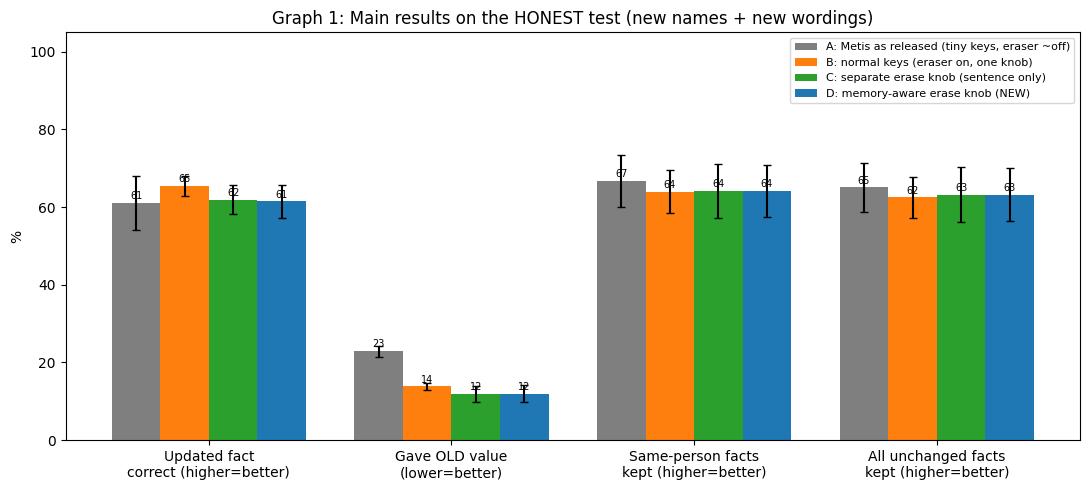

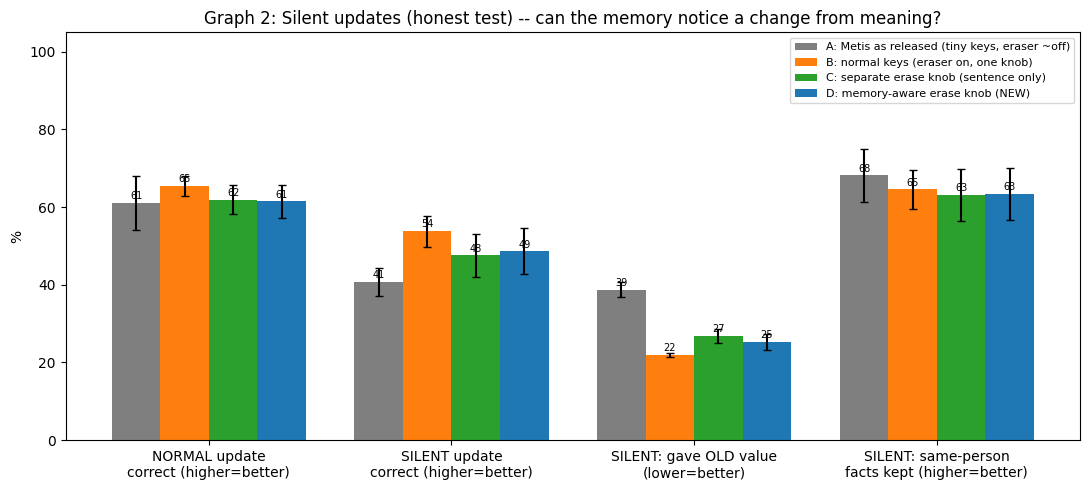

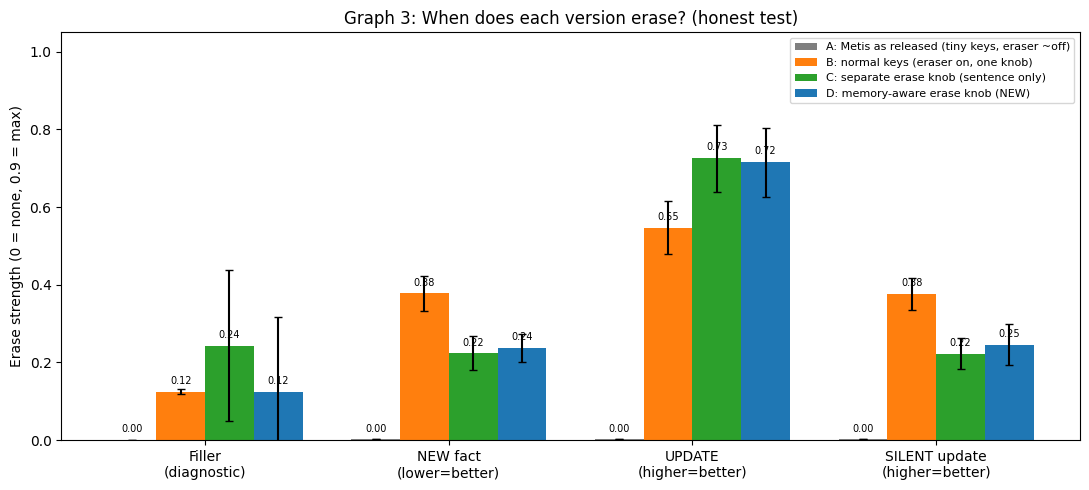

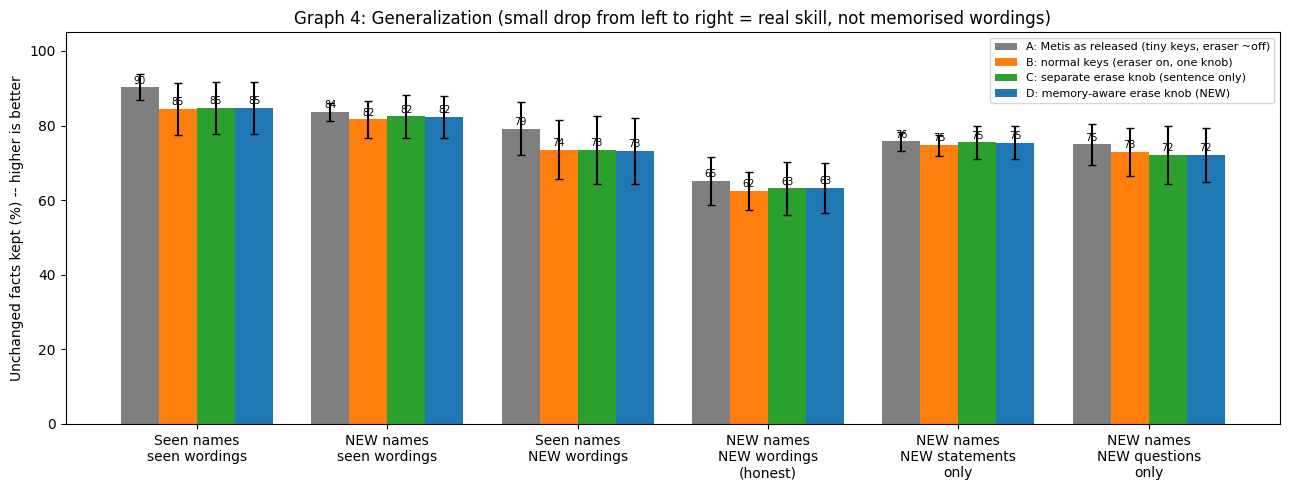

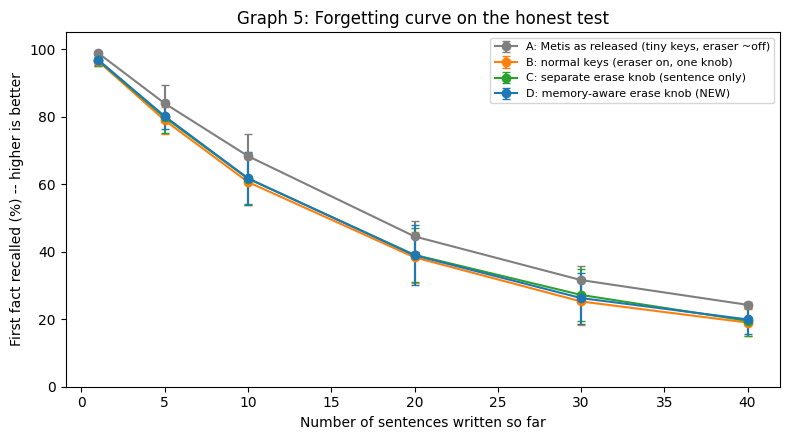

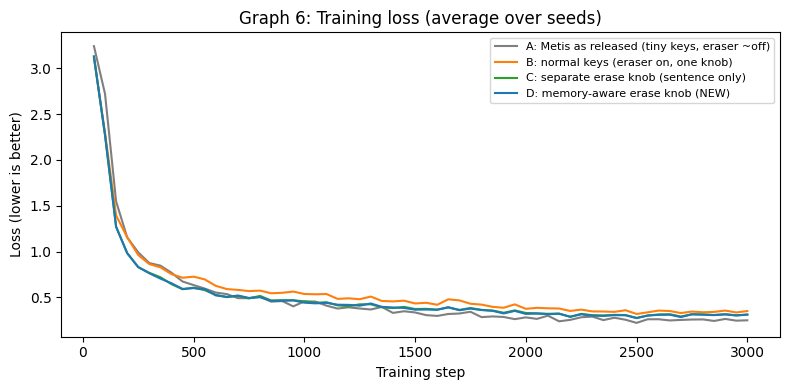

In [15]:
# CELL 15 -- Graphs
versions = VERSIONS_DONE


def bar_group(axis, metric_keys, labels, value_format="{:.0f}", offset_text=1.0):
    positions = np.arange(len(metric_keys))
    bar_width = 0.8 / len(versions)
    for version_index in range(len(versions)):
        version = versions[version_index]
        rows = rows_of(version)
        means = [rows[key].mean() for key in metric_keys]
        stds = [(rows[key].std() if len(rows) > 1 else 0.0) for key in metric_keys]
        offset = (version_index - (len(versions) - 1) / 2) * bar_width
        bars = axis.bar(positions + offset, means, bar_width, yerr=stds, capsize=3,
                        label=VERSION_DESCRIPTIONS[version], color=VERSION_COLORS[version])
        for bar, mean_value in zip(bars, means):
            axis.text(bar.get_x() + bar.get_width() / 2, mean_value + offset_text, value_format.format(mean_value),
                      ha="center", fontsize=7)
    axis.set_xticks(positions)
    axis.set_xticklabels(labels)


# Graph 1: main metrics on the honest test
figure, axis = plt.subplots(figsize=(11, 5))
bar_group(axis, ["honest_update_correct", "honest_update_gave_old", "honest_same_person_kept", "honest_unchanged_kept"],
          ["Updated fact\ncorrect (higher=better)", "Gave OLD value\n(lower=better)",
           "Same-person facts\nkept (higher=better)", "All unchanged facts\nkept (higher=better)"])
axis.set_ylim(0, 105)
axis.set_ylabel("%")
axis.set_title("Graph 1: Main results on the HONEST test (new names + new wordings)")
axis.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/graph1_main_honest.png", dpi=150)
plt.show()

# Graph 2: silent updates -- the test of fix 2
figure, axis = plt.subplots(figsize=(11, 5))
bar_group(axis, ["honest_update_correct", "silent_update_correct", "silent_update_gave_old", "silent_same_person_kept"],
          ["NORMAL update\ncorrect (higher=better)", "SILENT update\ncorrect (higher=better)",
           "SILENT: gave OLD value\n(lower=better)", "SILENT: same-person\nfacts kept (higher=better)"])
axis.set_ylim(0, 105)
axis.set_ylabel("%")
axis.set_title("Graph 2: Silent updates (honest test) -- can the memory notice a change from meaning?")
axis.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/graph2_silent_updates.png", dpi=150)
plt.show()

# Graph 3: erase strength by sentence type
figure, axis = plt.subplots(figsize=(11, 5))
bar_group(axis, ["honest_erase_on_filler", "honest_erase_on_new_fact", "honest_erase_on_update", "silent_erase_on_update"],
          ["Filler\n(diagnostic)", "NEW fact\n(lower=better)", "UPDATE\n(higher=better)", "SILENT update\n(higher=better)"],
          value_format="{:.2f}", offset_text=0.02)
axis.set_ylim(0, 1.05)
axis.set_ylabel("Erase strength (0 = none, 0.9 = max)")
axis.set_title("Graph 3: When does each version erase? (honest test)")
axis.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/graph3_erase_by_type.png", dpi=150)
plt.show()

# Graph 4: generalization -- unchanged facts kept under the six test conditions
figure, axis = plt.subplots(figsize=(13, 5))
bar_group(axis, [f"{condition}_unchanged_kept" for condition in GENERALIZATION_CONDITIONS],
          ["Seen names\nseen wordings", "NEW names\nseen wordings", "Seen names\nNEW wordings",
           "NEW names\nNEW wordings\n(honest)", "NEW names\nNEW statements\nonly", "NEW names\nNEW questions\nonly"])
axis.set_ylim(0, 105)
axis.set_ylabel("Unchanged facts kept (%) -- higher is better")
axis.set_title("Graph 4: Generalization (small drop from left to right = real skill, not memorised wordings)")
axis.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/graph4_generalization.png", dpi=150)
plt.show()

# Graph 5: forgetting curve
figure, axis = plt.subplots(figsize=(8, 4.5))
for version in versions:
    rows = rows_of(version)
    means = [rows[f"long_first_after_{n}"].mean() for n in CONFIG["long_checkpoints"]]
    stds = [(rows[f"long_first_after_{n}"].std() if len(rows) > 1 else 0.0) for n in CONFIG["long_checkpoints"]]
    axis.errorbar(CONFIG["long_checkpoints"], means, yerr=stds, marker="o", capsize=3,
                  label=VERSION_DESCRIPTIONS[version], color=VERSION_COLORS[version])
axis.set_xlabel("Number of sentences written so far")
axis.set_ylabel("First fact recalled (%) -- higher is better")
axis.set_ylim(0, 105)
axis.set_title("Graph 5: Forgetting curve on the honest test")
axis.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/graph5_forgetting_curve.png", dpi=150)
plt.show()

# Graph 6: training loss
figure, axis = plt.subplots(figsize=(8, 4))
for version in versions:
    curves = []
    steps = None
    for seed in CONFIG["seeds"]:
        key = f"{version}_seed{seed}"
        if key in LOSS_CURVES and len(LOSS_CURVES[key]) > 0:
            curves.append([point["loss"] for point in LOSS_CURVES[key]])
            if steps is None:
                steps = [point["step"] for point in LOSS_CURVES[key]]
    if len(curves) > 0:
        shortest = min(len(curve) for curve in curves)
        average_curve = np.mean([curve[:shortest] for curve in curves], axis=0)
        axis.plot(steps[:shortest], average_curve, label=VERSION_DESCRIPTIONS[version], color=VERSION_COLORS[version])
axis.set_xlabel("Training step")
axis.set_ylabel("Loss (lower is better)")
axis.set_title("Graph 6: Training loss (average over seeds)")
axis.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/graph6_loss.png", dpi=150)
plt.show()

## How the final decision is made (rules fixed before running)

All numbers come from the **honest test** (new names + new wordings). A difference only counts if it holds in **at least 80% of seeds** (4 of 5).

| Check | Question | Rule |
|---|---|---|
| **G** | Did fix 1 make the test bed trustworthy? | average "unchanged facts kept" ≥ 65% = strong, ≥ 55% = usable, below = not trustworthy |
| **E** | Does the eraser finding (B > A) hold up? | B beats A on updates by ≥ 5 points |
| **M** | Does D's gate react to *meaning*? | D erases on silent updates ≥ 0.5 × its erase on normal updates, **and** erases on new facts ≤ 0.5 × its erase on silent updates |
| **S** | Does D fix what C could not? | D beats C on silent updates by ≥ 5 points |
| **X** | Does D beat the simple fix? | D beats B on silent **or** normal updates by ≥ 3 points |
| **SAFE** | Does D avoid damaging other facts? | D is at most 3 points below B on unchanged facts and same-person facts (normal and silent stories) |

| Outcome | When | What it means for you |
|---|---|---|
| **PROCEED – the idea works** | G usable + M + S + X + SAFE | D is your capstone contribution. Stop adding ideas; polish and write it up. |
| **PROCEED – partial win** | G usable + M + S + SAFE, but not X | D reads meaning better than C, but the simple fix is competitive. Present D as a mechanism result. Stop adding ideas and write up. |
| **STOP EXPERIMENTING – WRITE UP** | G usable, D fails, but E holds | Your result is the eraser finding plus the honest analysis of why content-only gates fail. Write up now. |
| **MOVE ON** | G usable, but both E and D fail | The premise does not survive a fair test. Present it as a negative result, or discuss a new direction with your supervisor. |
| **STOP EXPERIMENTING – test bed still weak** | G not usable | The setup still cannot generalise, so more ideas will not give trustworthy answers. Write up what is solid, with the generalisation limit stated. |

In [16]:
# CELL 16 -- FINAL DECISION (rules fixed in CONFIG before running; all numbers from the HONEST test)


def mean_of(version, column):
    return rows_of(version)[column].mean()


def paired(first, second, column, higher_is_better=True):
    # Returns (mean difference first-second, number of seeds in the good direction, number of seeds)
    differences = paired_differences(first, second, column)
    if len(differences) == 0:
        return float("nan"), 0, 0
    good = int((differences > 0).sum()) if higher_is_better else int((differences < 0).sum())
    return float(differences.mean()), good, len(differences)


def consistent(good, total):
    return total > 0 and good / total >= CONFIG["seed_agreement"]


missing = [version for version in ["A", "B", "C", "D"] if version not in VERSIONS_DONE]
if missing:
    raise RuntimeError(f"Versions {missing} have no finished runs yet -- run Cell 13 to completion first.")
seeds_complete = min(SEEDS_PER_VERSION.values())

# ---- G: did fix 1 work? -------------------------------------------------------------------------
gen_value = float(np.mean([mean_of(v, "honest_unchanged_kept") for v in VERSIONS_DONE]))
gen_gap = float(np.mean([mean_of(v, "seen_unchanged_kept") - mean_of(v, "honest_unchanged_kept") for v in VERSIONS_DONE]))
if gen_value >= CONFIG["gen_strong"]:
    gen_level = "STRONG"
elif gen_value >= CONFIG["gen_weak"]:
    gen_level = "USABLE"
else:
    gen_level = "NOT TRUSTWORTHY"
G_pass = gen_level != "NOT TRUSTWORTHY"

# ---- E: does the eraser finding (B > A) replicate? ----------------------------------------------
e_diff, e_good, e_n = paired("B", "A", "honest_update_correct")
e_old_diff, e_old_good, _ = paired("B", "A", "honest_update_gave_old", higher_is_better=False)
E_pass = e_diff >= CONFIG["eraser_margin"] and consistent(e_good, e_n)

# ---- M: does D's gate react to MEANING? ---------------------------------------------------------
D_erase_update = mean_of("D", "honest_erase_on_update")
D_erase_silent = mean_of("D", "silent_erase_on_update")
D_erase_new = mean_of("D", "honest_erase_on_new_fact")
C_erase_update = mean_of("C", "honest_erase_on_update")
C_erase_silent = mean_of("C", "silent_erase_on_update")
C_erase_new = mean_of("C", "honest_erase_on_new_fact")
M_pass = (D_erase_silent >= CONFIG["mechanism_ratio"] * D_erase_update) and \
         (D_erase_new <= CONFIG["mechanism_ratio"] * D_erase_silent)

# ---- S: does D beat C on silent updates? --------------------------------------------------------
s_diff, s_good, s_n = paired("D", "C", "silent_update_correct")
S_pass = s_diff >= CONFIG["silent_margin"] and consistent(s_good, s_n)

# ---- X: does D beat the simple fix B? -----------------------------------------------------------
xs_diff, xs_good, xs_n = paired("D", "B", "silent_update_correct")
xn_diff, xn_good, xn_n = paired("D", "B", "honest_update_correct")
X_silent = xs_diff >= CONFIG["beat_simple_fix_margin"] and consistent(xs_good, xs_n)
X_normal = xn_diff >= CONFIG["beat_simple_fix_margin"] and consistent(xn_good, xn_n)
X_pass = X_silent or X_normal

# ---- SAFE: D does not damage facts that did not change (vs B) ------------------------------------
safety_columns = ["honest_unchanged_kept", "honest_same_person_kept", "silent_unchanged_kept", "silent_same_person_kept"]
safety_gaps = {column: mean_of("D", column) - mean_of("B", column) for column in safety_columns}
SAFE_pass = min(safety_gaps.values()) >= -CONFIG["damage_tolerance"]

checks = [
    ("G", "Fix 1 worked: the test bed generalises to new wordings", G_pass,
     f"avg honest unchanged kept {gen_value:.1f}% -> {gen_level} (Notebook 3: ~54%) | "
     f"seen-minus-honest gap {gen_gap:.1f} points (Notebook 3: ~35)"),
    ("E", f"Eraser finding holds: B beats A on updates by >= {CONFIG['eraser_margin']:.0f} points", E_pass,
     f"B-A = {e_diff:+.1f} points ({e_good}/{e_n} seeds) | stale answers B-A = {e_old_diff:+.1f} ({e_old_good}/{e_n} seeds lower)"),
    ("M", "D's gate reacts to MEANING (erases on silent updates, not on new facts)", M_pass,
     f"D erase: silent {D_erase_silent:.3f} | normal update {D_erase_update:.3f} | new fact {D_erase_new:.3f}   "
     f"(C for comparison: silent {C_erase_silent:.3f} | update {C_erase_update:.3f} | new fact {C_erase_new:.3f})"),
    ("S", f"D fixes what C could not: D beats C on silent updates by >= {CONFIG['silent_margin']:.0f} points", S_pass,
     f"D-C = {s_diff:+.1f} points ({s_good}/{s_n} seeds) | D {mean_of('D', 'silent_update_correct'):.1f}% vs "
     f"C {mean_of('C', 'silent_update_correct'):.1f}%"),
    ("X", f"D beats the simple fix B by >= {CONFIG['beat_simple_fix_margin']:.0f} points (silent or normal updates)", X_pass,
     f"silent: D-B = {xs_diff:+.1f} ({xs_good}/{xs_n} seeds) | normal: D-B = {xn_diff:+.1f} ({xn_good}/{xn_n} seeds)"),
    ("SAFE", f"D does not damage unchanged facts (at most {CONFIG['damage_tolerance']:.0f} points below B)", SAFE_pass,
     " | ".join(f"{column.replace('_', ' ')}: {gap:+.1f}" for column, gap in safety_gaps.items())),
]

print("=" * 100)
print("CHECKS (rules fixed in CONFIG before running; all from the HONEST test unless marked silent)")
print("=" * 100)
for code, description, passed_check, numbers in checks:
    print(f"[{'PASS' if passed_check else 'FAIL'}] {code:4s} {description}")
    print(f"             {numbers}")

# ---- The decision -------------------------------------------------------------------------------
notes = []
if not G_pass:
    decision = "STOP EXPERIMENTING -- TEST BED STILL WEAK"
    answer = "Do NOT start new experiments. Write up what is solid."
    meaning = ("Even with 3x more wordings, the memory does not generalise well enough to new wordings, so the\n"
               "differences between versions cannot be trusted. More ideas on top of this setup will not give\n"
               "clean answers inside a capstone timeline.")
    next_steps = ["Write up: (1) the eraser analysis of released Metis, (2) C learns WHEN to erase without supervision,",
                  "(3) content-only gates cannot see silent updates, (4) generalisation to new wordings as the main limitation.",
                  "Use Table 2 + the DIAGNOSIS line to explain WHERE generalisation fails (statements or questions)."]
    if M_pass and S_pass:
        notes.append("D shows a promising signal (checks M and S pass), but on a test bed this weak it is not reliable.")
        notes.append("Mention it as preliminary evidence and future work, not as a main result.")
elif M_pass and S_pass and SAFE_pass and X_pass:
    decision = "PROCEED -- THE IDEA WORKS"
    answer = "YES, proceed. D (memory-aware erase gate) is your capstone contribution."
    meaning = ("D notices changes from MEANING (not from words like 'moved'), fixes silent updates that C cannot,\n"
               "beats the simple fix B, and does not damage other facts.")
    next_steps = ["Stop adding new ideas. Freeze this setup as the main experiment.",
                  "Write up: problem (eraser off in released Metis) -> C (knows WHEN, only from words) -> D (knows from MEANING).",
                  "Only if time allows: one extra ablation (remove one of D's memory signals) to show which signal matters.",
                  "Show your supervisor Graph 2 and Graph 3 -- this is the kind of progress that can unlock a stronger GPU."]
elif M_pass and S_pass and SAFE_pass:
    decision = "PROCEED -- PARTIAL WIN"
    answer = "YES, proceed to the write-up. Present D as a mechanism result; do not add new ideas."
    meaning = ("D clearly reads MEANING and fixes silent updates better than C, without damaging other facts,\n"
               "but it does not clearly beat the simple fix B. The honest story: a memory-aware gate is needed to\n"
               "SEE silent updates, while simply turning the eraser on is already a strong baseline.")
    next_steps = ["Stop adding new ideas. Write up the three-step story (A -> B/C -> D) with Graphs 2 and 3.",
                  "Frame D's contribution as 'the gate learns WHEN to erase from memory content', not as 'best accuracy'."]
elif M_pass and S_pass and not SAFE_pass:
    decision = "PROCEED -- PARTIAL WIN WITH A COST"
    answer = "YES, proceed to the write-up, but report the trade-off honestly. Do not add new ideas."
    meaning = ("D fixes silent updates better than C and reads meaning, but it damages facts that did not change\n"
               "(see the SAFE line). That is a real trade-off, not a failure: erasing on meaning also hits\n"
               "neighbouring facts of the same person.")
    next_steps = ["Write up D with the trade-off (SAFE numbers) as an explicit finding.",
                  "Mention a fix as future work (e.g. penalising erase on new facts), do not try it now."]
elif E_pass:
    decision = "STOP EXPERIMENTING -- WRITE UP"
    answer = "Do not switch topics, but stop experimenting. Your result is the eraser finding + the analysis."
    meaning = ("On a better test bed, turning the eraser on (B) still clearly helps, which is your solid finding.\n"
               "The memory-aware gate (D) did not deliver what it was designed for.")
    next_steps = ["Write up: (1) released Metis effectively disables its eraser, (2) enabling it helps updates,",
                  "(3) C learns WHEN to erase without supervision, (4) sentence-only gates cannot detect silent updates,",
                  "(5) D was a principled attempt to fix (4); report it honestly as a negative result."]
else:
    decision = "MOVE ON (or present as a negative result)"
    answer = "The premise does not survive a fair test. Discuss with your supervisor before investing more time."
    meaning = ("With better generalisation, neither the eraser finding (B > A) nor the memory-aware gate (D) holds up.\n"
               "The earlier B > A gap was probably tied to the poor generalisation in Notebook 3.")
    next_steps = ["Option 1: present the full investigation as a careful negative result (this is still a valid capstone).",
                  "Option 2: talk to your supervisor about a new direction."]

if seeds_complete < len(CONFIG["seeds"]):
    notes.append(f"Only {seeds_complete} of {len(CONFIG['seeds'])} seeds finished for every version -- "
                 "treat this decision as preliminary and re-run Cell 13 to finish the remaining seeds.")
if seeds_complete < 3:
    notes.append("Fewer than 3 seeds: the seed-agreement rule is very weak. Do not rely on this decision yet.")
if gen_level == "USABLE":
    notes.append("The test bed is USABLE but not STRONG: say so in the write-up.")

print()
print("#" * 100)
print(f"#  FINAL DECISION:  {decision}")
print("#" * 100)
print(f"\nANSWER: {answer}\n")
print("WHY:")
print(meaning)
print("\nWHAT TO DO NEXT:")
for step in next_steps:
    print("  -", step)
if notes:
    print("\nNOTES:")
    for note in notes:
        print("  !", note)

decision_record = {
    "decision": decision, "answer": answer, "why": meaning, "next_steps": next_steps, "notes": notes,
    "seeds_complete": seeds_complete, "generalisation_level": gen_level,
    "checks": [{"check": code, "description": description, "passed": bool(passed_check), "numbers": numbers}
               for code, description, passed_check, numbers in checks],
}
with open(f"{OUTPUT_DIR}/decision.json", "w") as file:
    json.dump(decision_record, file, indent=2)
with open(f"{OUTPUT_DIR}/decision.txt", "w") as file:
    file.write(f"FINAL DECISION: {decision}\n\nANSWER: {answer}\n\nWHY:\n{meaning}\n\nWHAT TO DO NEXT:\n")
    file.write("\n".join("  - " + step for step in next_steps) + "\n")
    if notes:
        file.write("\nNOTES:\n" + "\n".join("  ! " + note for note in notes) + "\n")
    file.write("\nCHECKS:\n")
    for code, description, passed_check, numbers in checks:
        file.write(f"[{'PASS' if passed_check else 'FAIL'}] {code} {description}\n        {numbers}\n")
print("\nSaved decision.json and decision.txt in", OUTPUT_DIR)

CHECKS (rules fixed in CONFIG before running; all from the HONEST test unless marked silent)
[PASS] G    Fix 1 worked: the test bed generalises to new wordings
             avg honest unchanged kept 63.5% -> USABLE (Notebook 3: ~54%) | seen-minus-honest gap 22.5 points (Notebook 3: ~35)
[FAIL] E    Eraser finding holds: B beats A on updates by >= 5 points
             B-A = +4.4 points (2/3 seeds) | stale answers B-A = -9.1 (3/3 seeds lower)
[FAIL] M    D's gate reacts to MEANING (erases on silent updates, not on new facts)
             D erase: silent 0.246 | normal update 0.716 | new fact 0.237   (C for comparison: silent 0.223 | update 0.726 | new fact 0.223)
[FAIL] S    D fixes what C could not: D beats C on silent updates by >= 5 points
             D-C = +1.0 points (3/3 seeds) | D 48.6% vs C 47.6%
[FAIL] X    D beats the simple fix B by >= 3 points (silent or normal updates)
             silent: D-B = -5.2 (0/3 seeds) | normal: D-B = -3.9 (0/3 seeds)
[PASS] SAFE D does not damag

In [17]:
# CELL 17 -- A human-readable example for your presentation:
# one SILENT-update story from the honest test. How strongly do C and D erase at each sentence,
# and what do all four versions answer?
demo_seed = CONFIG["seeds"][0]
demo_episode = TEST_SETS["silent"][0]
demo_batch = standard_episodes_to_batch([demo_episode])

demo_answers, demo_erase = {}, {}
for version in VERSIONS_DONE:
    model_file = f"{OUTPUT_DIR}/model_{version}_seed{demo_seed}.pt"
    if not os.path.exists(model_file):
        continue
    model = NativeMemory(FEATURE_SIZE, CONFIG["memory_size"], len(ANSWERS), version).to(DEVICE)
    model.load_state_dict(torch.load(model_file, map_location=DEVICE))
    model.eval()
    with torch.no_grad():
        logits, erase_amounts = run_standard_batch(model, demo_batch)
    demo_answers[version] = [ANSWERS[index] for index in logits.argmax(dim=-1)[0].tolist()]
    demo_erase[version] = erase_amounts[0].tolist()
    del model

print("STORY (new names, new wordings, the change is written as a plain statement):")
header = "".join(f"  erase {version}" for version in ["C", "D"] if version in demo_erase)
print(f"{'':4s}{'sentence':66s}{header}")
for step_number in range(len(demo_episode["writes"])):
    write = demo_episode["writes"][step_number]
    marker = "  <-- SILENT UPDATE" if write["kind"] == "update" else ""
    erase_text = "".join(f"  {demo_erase[version][step_number]:7.3f}" for version in ["C", "D"] if version in demo_erase)
    print(f"{step_number + 1:2d}. {ALL_SENTENCES[write['sid']][:64]:66s}{erase_text}{marker}")

print("\nQUESTIONS:")
for query_number in range(len(demo_episode["queries"])):
    query = demo_episode["queries"][query_number]
    marker = f"  <-- UPDATED (old: {query['old_answer']})" if query["updated"] else ""
    print(f"\n  {ALL_SENTENCES[query['sid']]}  (correct: {query['answer']}){marker}")
    for version in demo_answers:
        answer = demo_answers[version][query_number]
        tick = "✓" if answer == query["answer"] else "✗"
        print(f"     {VERSION_DESCRIPTIONS[version]:48s} -> {answer:12s} {tick}")

STORY (new names, new wordings, the change is written as a plain statement):
    sentence                                                            erase C  erase D
 1. Rafi Dubois resides in Dubai.                                         0.390    0.356
 2. Joon Russo occupies a home in Seoul.                                  0.346    0.379
 3. Joon Russo craves dumplings above all else.                           0.289    0.327
 4. Joon Russo's beloved pet is a goldfish.                               0.129    0.170
 5. Joon Russo keeps a dog at home.                                       0.266    0.323  <-- SILENT UPDATE
 6. Traffic was heavy downtown.                                           0.171    0.221
 7. Rafi Dubois's number one food is waffles.                             0.327    0.345
 8. Rafi Dubois spends weekends on gardening.                             0.308    0.326
 9. The hallway light is dim.                                             0.050    0.061
10. The shade 

In [18]:
# CELL 18 -- Pack the results (tables, graphs, json) into one small zip to download
# Model weights (.pt) and the big features file are left out to keep the zip small.
results_folder = "/kaggle/working/notebook4_results"
if os.path.exists(results_folder):
    shutil.rmtree(results_folder)
os.makedirs(results_folder)
for file_name in os.listdir(OUTPUT_DIR):  # includes decision.json and decision.txt
    if file_name.endswith((".json", ".csv", ".png", ".txt")):
        shutil.copy(os.path.join(OUTPUT_DIR, file_name), results_folder)
zip_path = shutil.make_archive("/kaggle/working/notebook4_results", "zip", results_folder)
print("Download this file:", zip_path)
print("Contains:", sorted(os.listdir(results_folder)))

Download this file: /kaggle/working/notebook4_results.zip
Contains: ['decision.json', 'decision.txt', 'graph1_main_honest.png', 'graph2_silent_updates.png', 'graph3_erase_by_type.png', 'graph4_generalization.png', 'graph5_forgetting_curve.png', 'graph6_loss.png', 'loss_curves.json', 'results.json', 'table1_main_honest.csv', 'table2_generalization.csv', 'table3_erase.csv', 'table4_silent_updates.csv', 'table5_forgetting_curve.csv', 'table6_paired_differences.csv']
